# Docquity Doctor Search Assessment

This notebook covers Task 1 intent classification and Task 2 query-to-content retrieval for the Senior Data Scientist NLP technical assessment.

## Phase 0: Setup

Project-wide configuration lives in `src/config.py` so notebook runs, scripts, and exported outputs share the same paths, random seed, split settings, BM25 parameters, and evaluation cutoffs.

In [1]:
from src.config import CONFIG, set_random_seed
from src.data import load_all_raw

set_random_seed(CONFIG.random_seed)
raw = load_all_raw()
{name: df.shape for name, df in raw.items()}

{'queries': (500, 10),
 'content': (345, 14),
 'behavioral_signals': (1500, 8),
 'impressions': (7190, 6)}

## Phase 1: Data Audit

Audit raw queries, content metadata, behavioral signals, and impressions before defining labels or retrieval experiments.

### Phase 1 pipeline runners

These notebook-owned functions orchestrate the audit, schema design, and contextual-slot extraction. Their reusable helper logic remains in `src/`.

In [2]:
# Phase-level orchestration is kept in this main notebook for reviewer visibility.
# Detailed, reusable helpers remain in src/.

import json
from pathlib import Path
import pandas as pd

from src.audit import (
    AUDIT_DIR,
    AuditPaths,
    audit_behavioral_signals,
    audit_content,
    audit_impressions,
    audit_queries,
    write_report as write_audit_report,
)
from src.config import PROCESSED_DATA_DIR, set_random_seed
from src.data import load_all_raw, load_content, load_queries
from src.query_schema import (
    SCHEMA_DIR,
    build_candidate_profile,
    build_schema_table,
    write_schema_report,
)
from src.query_extraction import (
    ENRICHED_QUERIES_PATH,
    EXTRACTION_EXAMPLES_PATH,
    EXTRACTION_QA_PATH,
    EXTRACTION_REPORT_PATH,
    EXTRACTION_SUMMARY_PATH,
    PHASE16_DIR,
    build_examples,
    build_quality_review_sample,
    build_summary,
    enrich_queries,
    write_report as write_extraction_report,
)

def run_phase1_audit() -> AuditPaths:
    set_random_seed()
    AUDIT_DIR.mkdir(parents=True, exist_ok=True)
    paths = AuditPaths(
        report=AUDIT_DIR / "phase1_data_audit.md",
        metrics=AUDIT_DIR / "phase1_metrics.json",
        query_manual_review=AUDIT_DIR / "phase1_query_manual_review.csv",
        query_near_duplicates=AUDIT_DIR / "phase1_query_near_duplicates.csv",
        content_near_duplicates=AUDIT_DIR / "phase1_content_near_duplicates.csv",
        suspicious_behavior=AUDIT_DIR / "phase1_suspicious_behavior.csv",
        table_dir=AUDIT_DIR / "tables",
    )
    data = load_all_raw()
    metrics = {
        "queries": audit_queries(data["queries"], paths),
        "content": audit_content(data["content"], paths),
        "behavioral_signals": audit_behavioral_signals(data["behavioral_signals"], paths),
        "impressions": audit_impressions(data["impressions"], data["behavioral_signals"], paths),
    }
    paths.metrics.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
    write_audit_report(paths, metrics)
    return paths


def run_phase15_schema() -> dict[str, Path]:
    queries = load_queries()
    content = load_content()
    SCHEMA_DIR.mkdir(parents=True, exist_ok=True)

    candidate_profile = build_candidate_profile(queries, content)
    schema_table = build_schema_table()

    candidate_path = SCHEMA_DIR / "phase15_candidate_slot_profile.csv"
    schema_path = SCHEMA_DIR / "phase15_extended_query_schema.csv"
    report_path = SCHEMA_DIR / "phase15_extended_query_schema.md"

    candidate_profile.to_csv(candidate_path, index=False)
    schema_table.to_csv(schema_path, index=False)
    write_schema_report(report_path, candidate_profile, schema_table)

    return {
        "report": report_path,
        "schema": schema_path,
        "candidate_profile": candidate_path,
    }


def run_phase16_extraction() -> dict[str, Path]:
    set_random_seed()
    PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
    PHASE16_DIR.mkdir(parents=True, exist_ok=True)

    queries = load_queries()
    enriched = enrich_queries(queries)
    summary = build_summary(enriched)
    slot_columns = summary["column"].tolist()
    any_slot_mask = pd.Series(False, index=enriched.index)
    for column in slot_columns:
        if enriched[column].dtype == bool:
            any_slot_mask |= enriched[column]
        else:
            any_slot_mask |= enriched[column].notna()
    summary.attrs["queries_with_any_slot"] = int(any_slot_mask.sum())
    examples = build_examples(enriched)
    qa_sample = build_quality_review_sample(enriched)

    enriched.to_csv(ENRICHED_QUERIES_PATH, index=False)
    summary.to_csv(EXTRACTION_SUMMARY_PATH, index=False)
    examples.to_csv(EXTRACTION_EXAMPLES_PATH, index=False)
    qa_sample.to_csv(EXTRACTION_QA_PATH, index=False)
    write_extraction_report(EXTRACTION_REPORT_PATH, ENRICHED_QUERIES_PATH, summary, examples, qa_sample)

    return {
        "enriched_queries": ENRICHED_QUERIES_PATH,
        "summary": EXTRACTION_SUMMARY_PATH,
        "examples": EXTRACTION_EXAMPLES_PATH,
        "qa_sample": EXTRACTION_QA_PATH,
        "report": EXTRACTION_REPORT_PATH,
    }

In [3]:
phase1_audit_paths = run_phase1_audit()
phase15_schema_paths = run_phase15_schema()
phase16_extraction_paths = run_phase16_extraction()

{
    "phase1_report": phase1_audit_paths.report,
    "phase15_report": phase15_schema_paths["report"],
    "phase16_report": phase16_extraction_paths["report"],
}

{'phase1_report': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/audits/phase1_data_audit.md'),
 'phase15_report': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/schema/phase15_extended_query_schema.md'),
 'phase16_report': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/schema/phase16_contextual_extraction.md')}

## Phase 2: Literature-Seeded Intent Taxonomy Refinement

The literature taxonomy is a seed rather than a fixed label set. The analysis combines delexicalized word unigram/bigram TF-IDF, cached frozen multilingual MiniLM embeddings, 13 structured NER/context features, prototype similarity and ambiguity margins, independent clustering, and manual clinical-coherence review. Final support is estimated with an explicit CPU adaptation of Liang et al.'s three-branch model: frozen semantic similarity, 200-feature sentence TF-IDF, and class-centroid TF-IDF are projected into a shared space, combined by learned sample-wise attention, and passed through a nonlinear classification head. Because Phase 2 has no gold labels, ordered boundary rules provide weak pseudo-labels where Liang's supervised model uses gold labels; reported validation measures weak-label agreement, not clinical accuracy.

Primary sources: [Monsalve et al. (2026)](https://doi.org/10.64898/2026.06.26.26356340) and [Liang et al. (2025)](https://doi.org/10.1038/s41598-025-25783-x).

### Phase 2 pipeline runner

This notebook-owned function exposes every Phase 2 substep in the main deliverable while delegating reusable algorithms to `src/taxonomy.py` and `src/liang_intent.py`.

In [4]:
# Phase 2 orchestration is defined here; reusable modeling helpers remain in src/taxonomy.py
# and src/liang_intent.py.

from dataclasses import asdict
import re

import numpy as np
from scipy.sparse import save_npz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from src.config import CACHE_DIR, CONFIG, FIGURES_DIR, PROCESSED_DATA_DIR, TAXONOMY_DIR
from src.taxonomy import (
    CANDIDATE_INTENTS,
    FEATURE_COLUMNS,
    INTENT_STOP_WORDS,
    SEED_INTENTS,
    _fit_cluster_models,
    _write_completion_checklist,
    _write_figures,
    _write_report,
    build_analysis_tables,
    build_manual_review,
    build_seed_to_final_derivation,
    build_structured_features,
    build_taxonomy_decisions,
    delexicalize_query,
    encode_texts,
    weak_anchor_assignment,
)
from src.liang_intent import (
    LiangAdaptationConfig,
    candidate_document,
    fit_liang_hybrid_intent_model,
)

def run_phase2_taxonomy(force_recompute_embeddings: bool = False) -> dict[str, Path]:
    """Run every Phase 2 substep and write its auditable artifacts."""
    set_random_seed()
    TAXONOMY_DIR.mkdir(parents=True, exist_ok=True)
    CACHE_DIR.mkdir(parents=True, exist_ok=True)

    queries_path = PROCESSED_DATA_DIR / "queries_with_contextual_slots.csv"
    queries = pd.read_csv(queries_path)
    queries["intent_text"] = queries.apply(delexicalize_query, axis=1)
    # Apply intent cues after entity replacement. Otherwise disease names such
    # as "Heart Failure" and "Hypertension in Pregnancy" leak the words
    # "failure" and "pregnancy" into the primary-intent estimate.
    anchors = queries["intent_text"].map(weak_anchor_assignment)
    queries[["anchor_rule_intent", "matched_candidate_intents", "n_anchor_matches"]] = pd.DataFrame(
        anchors.tolist(), index=queries.index
    )

    structured = build_structured_features(queries)
    vectorizer = TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        token_pattern=r"(?u)\b\w[\w+-]+\b",
        stop_words=list(INTENT_STOP_WORDS),
    )
    tfidf = vectorizer.fit_transform(queries["intent_text"])
    save_npz(CACHE_DIR / "phase2_tfidf_matrix.npz", tfidf)
    (CACHE_DIR / "phase2_tfidf_vocabulary.json").write_text(
        json.dumps({term: int(index) for term, index in vectorizer.vocabulary_.items()}, indent=2, sort_keys=True),
        encoding="utf-8",
    )

    prototype_texts = [intent.definition for intent in SEED_INTENTS]
    query_embeddings = encode_texts(
        queries["intent_text"].tolist(),
        CACHE_DIR / "phase2_query_embeddings.npz",
        force_recompute=force_recompute_embeddings,
    )
    prototype_embeddings = encode_texts(
        prototype_texts,
        CACHE_DIR / "phase2_prototype_embeddings.npz",
        force_recompute=force_recompute_embeddings,
    )
    candidate_documents = [candidate_document(intent) for intent in CANDIDATE_INTENTS]
    candidate_embeddings = encode_texts(
        candidate_documents,
        CACHE_DIR / "phase2_candidate_intent_embeddings.npz",
        force_recompute=force_recompute_embeddings,
    )
    prototype_scores = cosine_similarity(query_embeddings, prototype_embeddings)
    seed_names = [intent.literature_intent for intent in SEED_INTENTS]
    order = np.argsort(prototype_scores, axis=1)[:, ::-1]
    prototype_assignments = pd.DataFrame(
        {
            "query_id": queries["query_id"],
            "prototype_top_intent": [seed_names[i] for i in order[:, 0]],
            "prototype_top_score": prototype_scores[np.arange(len(queries)), order[:, 0]],
            "prototype_second_intent": [seed_names[i] for i in order[:, 1]],
            "prototype_second_score": prototype_scores[np.arange(len(queries)), order[:, 1]],
        }
    )
    prototype_assignments["ambiguity_margin"] = (
        prototype_assignments["prototype_top_score"] - prototype_assignments["prototype_second_score"]
    )
    prototype_assignments["margin_is_calibrated_confidence"] = False
    for i, name in enumerate(seed_names):
        safe_name = re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")
        prototype_assignments[f"similarity_{safe_name}"] = prototype_scores[:, i].round(6)
    queries["prototype_top_intent"] = prototype_assignments["prototype_top_intent"]

    # Liang et al. use gold labels for the class-centroid and supervised
    # attention branches. Phase 2 has no gold set, so the ordered,
    # delexicalized boundary policy supplies explicitly weak pseudo-labels.
    # A stratified holdout measures only agreement with those anchors; it must
    # not be presented as clinical accuracy.
    weak_anchor_labels = queries["anchor_rule_intent"].astype(str).tolist()
    liang_result = fit_liang_hybrid_intent_model(
        query_ids=queries["query_id"].astype(str).tolist(),
        query_texts=queries["intent_text"].astype(str).tolist(),
        query_embeddings=query_embeddings,
        candidates=CANDIDATE_INTENTS,
        candidate_embeddings=candidate_embeddings,
        anchor_labels=weak_anchor_labels,
        stop_words=INTENT_STOP_WORDS,
        config=LiangAdaptationConfig(random_seed=CONFIG.random_seed),
    )
    liang_assignments = liang_result.assignments.reset_index(drop=True)
    for column in liang_assignments.columns:
        if column != "query_id":
            queries[column] = liang_assignments[column].to_numpy()

    cluster_labels, comparison = _fit_cluster_models(query_embeddings)
    queries["cluster_id"] = cluster_labels
    analysis, explanations, profiles = build_analysis_tables(
        queries, structured, tfidf, vectorizer, query_embeddings, prototype_scores, cluster_labels
    )
    manual_review, ambiguity_review, cross_class = build_manual_review(
        queries, query_embeddings, prototype_assignments
    )
    decisions = build_taxonomy_decisions(queries)

    counts = queries["liang_final_intent"].value_counts()
    candidate_table = pd.DataFrame([asdict(intent) for intent in CANDIDATE_INTENTS])
    candidate_table["n_queries"] = candidate_table["intent_name"].map(counts).fillna(0).astype(int)
    candidate_table["support_estimation_method"] = (
        "Liang-style weakly supervised three-branch attention model"
    )
    candidate_table["support_decision"] = np.select(
        [candidate_table["n_queries"].ge(20), candidate_table["n_queries"].ge(10)],
        [">=20: standalone supported", "10-19: retain only after explicit manual exception"],
        default="<10: merge unless clinically essential",
    )
    # This is the actual model-supported final schema. Candidate definitions
    # are hypotheses; they become final only after passing the Phase 2 support
    # threshold. Clinically essential exceptions would require an explicit,
    # documented manual override (none are used in this run).
    final_table = candidate_table[candidate_table["n_queries"].ge(20)].copy()
    derivation = build_seed_to_final_derivation(final_table, liang_assignments, analysis)

    seed_table = pd.DataFrame([asdict(intent) for intent in SEED_INTENTS])
    assignment_export = queries[
        [
            "query_id",
            "query_text",
            "language",
            "intent_text",
            "cluster_id",
            "liang_final_intent",
            "liang_top_probability",
            "liang_second_intent",
            "liang_second_probability",
            "liang_probability_margin",
            "attention_semantic",
            "attention_sentence_tfidf",
            "attention_class_centroid_tfidf",
            "anchor_rule_intent",
            "matched_candidate_intents",
            "n_anchor_matches",
            "used_as_weak_anchor",
        ]
    ].merge(prototype_assignments, on="query_id", how="left")
    model_disagreements = assignment_export[
        assignment_export["liang_final_intent"].ne(assignment_export["anchor_rule_intent"])
    ].copy()
    model_disagreements["review_status"] = "requires Phase 3 adjudication"
    model_disagreements["interpretation"] = (
        "Liang-style model and weak anchor disagree; neither is a gold label"
    )

    paths = {
        "seed_taxonomy": TAXONOMY_DIR / "phase2_seed_taxonomy.csv",
        "prototype_assignments": TAXONOMY_DIR / "phase2_prototype_assignments.csv",
        "liang_assignments": TAXONOMY_DIR / "phase2_liang_hybrid_assignments.csv",
        "liang_branch_metrics": TAXONOMY_DIR / "phase2_liang_branch_metrics.csv",
        "liang_training_history": TAXONOMY_DIR / "phase2_liang_training_history.csv",
        "liang_methodology": TAXONOMY_DIR / "phase2_liang_methodology.json",
        "seed_to_final_derivation": TAXONOMY_DIR / "phase2_seed_to_final_derivation.csv",
        "model_disagreements": TAXONOMY_DIR / "phase2_liang_model_disagreements.csv",
        "cluster_comparison": TAXONOMY_DIR / "phase2_cluster_model_comparison.csv",
        "nlp_analysis": TAXONOMY_DIR / "phase2_nlp_taxonomy_analysis.csv",
        "tfidf_explanations": TAXONOMY_DIR / "phase2_tfidf_explanations.csv",
        "structured_profiles": TAXONOMY_DIR / "phase2_structured_feature_profiles.csv",
        "taxonomy_decisions": TAXONOMY_DIR / "phase2_taxonomy_decisions.csv",
        "manual_review": TAXONOMY_DIR / "phase2_manual_clinical_review.csv",
        "ambiguity_review": TAXONOMY_DIR / "phase2_low_margin_review.csv",
        "cross_class_review": TAXONOMY_DIR / "phase2_cross_class_neighbors.csv",
        "final_taxonomy": TAXONOMY_DIR / "phase2_final_taxonomy.csv",
        "structured_features": TAXONOMY_DIR / "phase2_structured_query_features.csv",
        "report": TAXONOMY_DIR / "phase2_taxonomy_report.md",
        "completion_checklist": TAXONOMY_DIR / "phase2_completion_checklist.md",
        "manifest": TAXONOMY_DIR / "phase2_manifest.json",
    }
    seed_table.to_csv(paths["seed_taxonomy"], index=False)
    assignment_export.to_csv(paths["prototype_assignments"], index=False)
    liang_assignments.to_csv(paths["liang_assignments"], index=False)
    liang_result.branch_metrics.to_csv(paths["liang_branch_metrics"], index=False)
    liang_result.training_history.to_csv(paths["liang_training_history"], index=False)
    paths["liang_methodology"].write_text(
        json.dumps(liang_result.methodology, indent=2), encoding="utf-8"
    )
    derivation.to_csv(paths["seed_to_final_derivation"], index=False)
    model_disagreements.to_csv(paths["model_disagreements"], index=False)
    save_npz(CACHE_DIR / "phase2_liang_tfidf_matrix.npz", liang_result.tfidf_matrix)
    np.save(CACHE_DIR / "phase2_liang_class_centroids.npy", liang_result.class_centroids)
    (CACHE_DIR / "phase2_liang_selected_features.json").write_text(
        json.dumps(liang_result.selected_tfidf_features, indent=2), encoding="utf-8"
    )
    comparison.to_csv(paths["cluster_comparison"], index=False)
    analysis.to_csv(paths["nlp_analysis"], index=False)
    explanations.to_csv(paths["tfidf_explanations"], index=False)
    profiles.to_csv(paths["structured_profiles"], index=False)
    decisions.to_csv(paths["taxonomy_decisions"], index=False)
    manual_review.to_csv(paths["manual_review"], index=False)
    ambiguity_review.to_csv(paths["ambiguity_review"], index=False)
    cross_class.to_csv(paths["cross_class_review"], index=False)
    final_table.to_csv(paths["final_taxonomy"], index=False)
    structured.to_csv(paths["structured_features"], index=False)
    _write_report(
        seed_table,
        analysis,
        final_table,
        decisions,
        comparison,
        prototype_assignments,
        manual_review,
        cross_class,
        derivation,
        liang_result.branch_metrics,
        liang_assignments,
    )
    _write_completion_checklist(
        int(comparison.loc[comparison["selected"], "n_clusters"].iloc[0])
    )
    _write_figures(queries, query_embeddings, cluster_labels)

    manifest = {
        "phase": 2,
        "n_queries": len(queries),
        "semantic_model": CONFIG.semantic_model_name,
        "semantic_model_frozen": True,
        "semantic_inference_device": "cpu",
        "query_embedding_shape": list(query_embeddings.shape),
        "prototype_embedding_shape": list(prototype_embeddings.shape),
        "candidate_intent_embedding_shape": list(candidate_embeddings.shape),
        "tfidf_shape": list(tfidf.shape),
        "structured_feature_count": len(FEATURE_COLUMNS),
        "selected_cluster_method": "agglomerative_cosine",
        "selected_n_clusters": int(comparison.loc[comparison["selected"], "n_clusters"].iloc[0]),
        "selected_silhouette_cosine": round(float(comparison.loc[comparison["selected"], "silhouette_cosine"].iloc[0]), 6),
        "final_taxonomy_size": len(final_table),
        "final_class_distribution": {str(k): int(v) for k, v in counts.sort_index().items()},
        "final_assignments_derived_by": "Liang-style three-branch attention model",
        "weak_anchor_rows": int(liang_assignments["used_as_weak_anchor"].sum()),
        "mean_attention_weights": {
            "semantic": round(float(liang_assignments["attention_semantic"].mean()), 6),
            "sentence_tfidf": round(float(liang_assignments["attention_sentence_tfidf"].mean()), 6),
            "class_centroid_tfidf": round(float(liang_assignments["attention_class_centroid_tfidf"].mean()), 6),
        },
        "liang_validation_metrics_are_gold_accuracy": False,
        "liang_model_anchor_disagreements": len(model_disagreements),
        "manual_review_rows": len(manual_review),
        "low_margin_review_rows": len(ambiguity_review),
        "cross_class_neighbor_pairs": len(cross_class),
        "gold_labels_created": False,
        "random_seed": CONFIG.random_seed,
        "artifacts": {key: str(path.relative_to(path.parents[2])) if path.is_relative_to(path.parents[2]) else str(path) for key, path in paths.items() if key != "manifest"},
    }
    paths["manifest"].write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    return paths

In [5]:
phase2_paths = run_phase2_taxonomy()
phase2_paths

{'seed_taxonomy': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/taxonomy/phase2_seed_taxonomy.csv'),
 'prototype_assignments': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/taxonomy/phase2_prototype_assignments.csv'),
 'liang_assignments': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/taxonomy/phase2_liang_hybrid_assignments.csv'),
 'liang_branch_metrics': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/taxonomy/phase2_liang_branch_metrics.csv'),
 'liang_training_history': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/taxonomy/phase2_liang_training_history.csv'),
 'liang_methodology': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/taxonomy/phase2_liang_methodology.json'),
 'seed_to_final_derivation': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/taxonomy/phase2_seed_to_final_derivation.csv'),
 'model_disagreements': PosixPath('/Users/hol/Docume

In [6]:
from pathlib import Path
import pandas as pd
from IPython.display import display
from src.config import TAXONOMY_DIR

seed_taxonomy = pd.read_csv(TAXONOMY_DIR / 'phase2_seed_taxonomy.csv')
cluster_analysis = pd.read_csv(TAXONOMY_DIR / 'phase2_nlp_taxonomy_analysis.csv')
final_taxonomy = pd.read_csv(TAXONOMY_DIR / 'phase2_final_taxonomy.csv')
taxonomy_decisions = pd.read_csv(TAXONOMY_DIR / 'phase2_taxonomy_decisions.csv')
prototype_assignments = pd.read_csv(TAXONOMY_DIR / 'phase2_prototype_assignments.csv')
liang_assignments = pd.read_csv(TAXONOMY_DIR / 'phase2_liang_hybrid_assignments.csv')
liang_branch_metrics = pd.read_csv(TAXONOMY_DIR / 'phase2_liang_branch_metrics.csv')
seed_to_final = pd.read_csv(TAXONOMY_DIR / 'phase2_seed_to_final_derivation.csv')

display(seed_taxonomy[['literature_intent', 'definition', 'source']])
display(liang_branch_metrics)
display(seed_to_final)
display(cluster_analysis)
display(taxonomy_decisions)
display(final_taxonomy)

,literature_intent,definition,source
0,Management / Treatment,"Queries asking how to manage a condition, choo...","Monsalve et al. (2026), Clinical Information N..."
1,Diagnosis / Differential Diagnosis,Queries asking which diagnosis explains observ...,"Monsalve et al. (2026), Clinical Information N..."
2,Work-up / Test Selection,"Queries asking which diagnostic test, imaging ...","Monsalve et al. (2026), Clinical Information N..."
3,Test / Clinical Data Interpretation,"Queries asking what an existing laboratory, im...","Monsalve et al. (2026), Clinical Information N..."
4,Pharmacotherapy,"Drug-centered queries about medication choice,...","Monsalve et al. (2026), Clinical Information N..."
5,Evidence / Guideline Lookup,"Queries seeking a guideline, recommendation, c...","Monsalve et al. (2026), Clinical Information N..."
6,Procedures / Techniques,Queries asking how to perform a clinical proce...,"Monsalve et al. (2026), Clinical Information N..."
7,Epidemiology / Prognosis,"Queries asking about frequency, risk, natural ...","Monsalve et al. (2026), Clinical Information N..."
8,Patient Communication / Education,"Queries asking how to explain a condition, res...","Monsalve et al. (2026), Clinical Information N..."
9,Other / Ambiguous,"Queries whose information need is unclear, gen...","Monsalve et al. (2026), Clinical Information N..."


,model,validation_rows,accuracy_vs_weak_anchor,macro_f1_vs_weak_anchor
0,semantic,100,0.53,0.529048
1,sentence_tfidf,100,0.83,0.864459
2,class_centroid_tfidf,100,0.89,0.912797
3,liang_three_branch_attention,100,0.99,0.994914


,seed_parent_intent,liang_subintent_analogue,candidate_final_intent,derivation_action,candidate_definition_source,liang_model_n_queries,mean_model_probability,mean_model_margin,dominant_independent_cluster_ids,support_decision,final_schema_status
0,Management / Treatment,therapy,Management / Treatment Selection,keep_and_rename,literature seed + Liang analogue + observed Do...,58,0.9293,0.8934,11,>=20: standalone supported,retain
1,Pharmacotherapy,therapy,Dosing / Administration,split,literature seed + Liang analogue + observed Do...,99,0.8254,0.7316,1; 3; 5; 8; 10,>=20: standalone supported,retain
2,Pharmacotherapy,caution / precautions,Safety / Contraindication,split,literature seed + Liang analogue + observed Do...,73,0.6634,0.4993,2; 4; 7; 12; 13; 14,>=20: standalone supported,retain
3,Pharmacotherapy,caution + therapy,Interaction / Combination,split,literature seed + Liang analogue + observed Do...,24,0.8896,0.8494,none,>=20: standalone supported,retain
4,Pharmacotherapy,effect / efficacy + therapy,Comparative Treatment Choice,split,literature seed + Liang analogue + observed Do...,23,0.9828,0.9759,none,>=20: standalone supported,retain
5,Management / Treatment; Epidemiology / Prognosis,caution + metric interpretation + prognosis,Monitoring / Response / Risk Assessment,merge_sparse_risk_with_monitoring,literature seed + Liang analogue + observed Do...,40,0.9417,0.9185,6; 9,>=20: standalone supported,retain
6,Pharmacotherapy; Epidemiology / Prognosis,effect / efficacy + outcome / prognosis,Efficacy / Outcomes,split_and_merge,literature seed + Liang analogue + observed Do...,20,0.9874,0.9812,none,>=20: standalone supported,retain
7,Evidence / Guideline Lookup,dataset-specific refinement of therapy/other,Guideline / Evidence Lookup,rename,literature seed + Liang analogue + observed Do...,59,0.8940,0.8297,none,>=20: standalone supported,retain
8,Management / Treatment,therapy,Treatment Change / Escalation,split,literature seed + Liang analogue + observed Do...,44,0.9809,0.9716,0,>=20: standalone supported,retain
9,Management / Treatment,therapy + caution,Prophylaxis / Maintenance,split,literature seed + Liang analogue + observed Do...,31,0.9765,0.9688,none,>=20: standalone supported,retain


,cluster_id,n_queries,nearest_seed_intent,mean_prototype_similarity,top_terms,dominant_entity_pattern,dominant_liang_final_intent,dominant_intent_share,representative_query_ids,proposed_action
0,0,216,Management / Treatment,0.4347,medicine disease; medicine medicine; vs medici...,"entities(disease=1.00, molecule=1.00, drug_cla...",Treatment Change / Escalation,0.1991,Q262; Q006; Q155; Q231; Q328,manual_review
1,1,34,Pharmacotherapy,0.3470,renal; disease renal; renal impairment; impair...,"entities(disease=1.00, molecule=1.00, drug_cla...",Dosing / Administration,0.5294,Q148; Q191; Q019; Q380; Q011,manual_review
2,2,14,Pharmacotherapy,0.3906,disease diabetes; diabetes; obesity; disease o...,"entities(disease=1.00, molecule=1.00, drug_cla...",Safety / Contraindication,0.5714,Q464; Q374; Q497; Q228; Q162,manual_review
3,3,21,Pharmacotherapy,0.3504,hepatic impairment; hepatic; impairment dose; ...,"entities(disease=1.00, molecule=1.00, drug_cla...",Dosing / Administration,0.7143,Q277; Q299; Q050; Q135; Q154,split
4,4,10,Pharmacotherapy,0.3924,copd; disease copd; ckd; disease ckd; kontrain...,"entities(disease=1.00, molecule=1.00, drug_cla...",Safety / Contraindication,0.6000,Q233; Q131; Q142; Q450; Q297,split
5,5,17,Epidemiology / Prognosis,0.3726,toleransi; dosis titrasi; disease toleransi; t...,"entities(disease=1.00, molecule=1.00, drug_cla...",Dosing / Administration,1.0000,Q220; Q294; Q069; Q110; Q139,split
6,6,88,Pharmacotherapy,0.5442,monitoring; mechanism; drugclass mechanism; pa...,"entities(disease=1.00, molecule=1.00, drug_cla...",Monitoring / Response / Risk Assessment,0.3409,Q237; Q418; Q498; Q259; Q174,manual_review
7,7,4,Evidence / Guideline Lookup,0.3917,heart; heart failure; disease heart; failure; ...,"entities(disease=1.00, molecule=1.00, drug_cla...",Safety / Contraindication,0.5000,Q125; Q475; Q222; Q132,manual_review
8,8,13,Pharmacotherapy,0.4277,elderly; disease perlu; perlu; medicine elderl...,"entities(disease=1.00, molecule=1.00, drug_cla...",Dosing / Administration,0.6923,Q411; Q270; Q249; Q239; Q161,split
9,9,8,Epidemiology / Prognosis,0.4127,risk stratification; stratification; stratific...,"entities(disease=1.00, molecule=1.00, drug_cla...",Monitoring / Response / Risk Assessment,1.0000,Q440; Q416; Q397; Q251; Q221,merge


,literature_or_candidate_intent,prototype_top1_count,decision,rationale
0,Management / Treatment,100,split,"Supported but heterogeneous; split selection, ..."
1,Diagnosis / Differential Diagnosis,20,merge,No coherent diagnosis-seeking template is pres...
2,Work-up / Test Selection,0,merge,No query asks which investigation to order; mo...
3,Test / Clinical Data Interpretation,0,merge,No query supplies an existing result for inter...
4,Pharmacotherapy,254,split,"Strong, retrieval-distinct dose, safety, inter..."
5,Evidence / Guideline Lookup,41,rename,Explicit guideline/latest/year language suppor...
6,Procedures / Techniques,11,merge,No coherent procedural-technique pocket is obs...
7,Epidemiology / Prognosis,74,merge,Treatment outcomes merge with Efficacy; eight ...
8,Patient Communication / Education,0,merge,No patient-facing explanation or counseling qu...
9,Other / Ambiguous,0,manual_review,"Retain as an annotation fallback, but no stand..."


,intent_name,parent_intent,definition,inclusion_criteria,exclusion_criteria,positive_examples,boundary_examples,likely_content_preference,taxonomy_action,n_queries,support_estimation_method,support_decision
0,Management / Treatment Selection,Management / Treatment,"Select, initiate, or sequence a treatment stra...","first-line choice, best therapy, treatment alg...","dose/titration, safety, explicit guideline loo...",treatment algorithm for diabetes; first-line d...,when to start a drug belongs here unless the q...,"treatment algorithms, society recommendations,...",keep_and_rename,58,Liang-style weakly supervised three-branch att...,>=20: standalone supported
1,Dosing / Administration,Pharmacotherapy,"Determine dose, titration, loading regimen, ro...","dose/dosis, titration/titrasi, loading dose, r...",general medication safety without a requested ...,metformin dose in CKD; amiodarone loading dose,a query containing both dose and 'safe' needs ...,"drug monographs, dosing tables, renal/hepatic ...",split,99,Liang-style weakly supervised three-branch att...,>=20: standalone supported
2,Safety / Contraindication,Pharmacotherapy,"Assess adverse effects, contraindications, pre...","safe/aman, contraindication, adverse/side effe...",explicit drug-drug interaction or a requested ...,ACE inhibitor pregnancy safety; statin liver s...,monitoring adverse effects is safety when harm...,"safety monographs, contraindication sections, ...",split,73,Liang-style weakly supervised three-branch att...,>=20: standalone supported
3,Interaction / Combination,Pharmacotherapy,Assess a drug-drug interaction or the rational...,"drug interaction/interaksi obat, combination t...",head-to-head comparison where alternatives are...,warfarin interaction with amiodarone; combinat...,combination safety remains here when co-admini...,"interaction databases, combination-regimen evi...",split,24,Liang-style weakly supervised three-branch att...,>=20: standalone supported
4,Comparative Treatment Choice,Pharmacotherapy,"Compare two named treatments, usually for rela...","vs/versus, compare, mana lebih efektif",co-administration interactions or a single tre...,apixaban vs warfarin; semaglutide vs liraglutide,two named drugs do not imply comparison withou...,"head-to-head trials, network meta-analyses, co...",split,23,Liang-style weakly supervised three-branch att...,>=20: standalone supported
5,Monitoring / Response / Risk Assessment,Management / Treatment; Epidemiology / Prognosis,"Select monitoring parameters, assess treatment...","monitoring parameters, biomarkers of response,...",adverse-effect lists without a monitoring deci...,monitoring parameters for apixaban; PE risk st...,adverse-effects monitoring may border Safety; ...,"monitoring protocols, biomarkers, validated ri...",merge_sparse_risk_with_monitoring,40,Liang-style weakly supervised three-branch att...,>=20: standalone supported
6,Efficacy / Outcomes,Pharmacotherapy; Epidemiology / Prognosis,"Assess therapeutic effect, clinical outcomes, ...","efficacy, clinical outcome data, long-term out...",explicit head-to-head comparison; disease prog...,SGLT2 efficacy outcomes; long-term outcomes of...,maintenance after target attainment is longitu...,"randomized trials, systematic reviews, outcome...",split_and_merge,20,Liang-style weakly supervised three-branch att...,>=20: standalone supported
7,Guideline / Evidence Lookup,Evidence / Guideline Lookup,"Retrieve an explicit guideline, recent update,...","guideline/panduan, latest/terbaru, evidence ba...",clinical choice without an explicit request fo...,latest COPD guideline; 2025 ACS evidence update,'when to start' plus evidence terbaru belongs ...,"current guidelines, consensus statements, evid...",rename,59,Liang-style weakly supervised three-branch att...,>=20: standalone supported
8,Treatment Change / Escalation,Management / Treatment,"Change, add, or escalate treatment because of ...","switch/penggantian, add-on, failure/gagal, res...",initial first-line

### Phase 2 decision

The 500-query sample supports 11 operational classes, all with at least 20 provisional examples: Management / Treatment Selection; Dosing / Administration; Safety / Contraindication; Interaction / Combination; Comparative Treatment Choice; Monitoring / Response / Risk Assessment; Efficacy / Outcomes; Guideline / Evidence Lookup; Treatment Change / Escalation; Prophylaxis / Maintenance; and Mechanism / Background Knowledge.

The broad Pharmacotherapy and Management seeds split into retrieval-distinct needs. Mechanism / Background Knowledge is added because it is coherent and supported. Eight risk-stratification queries merge with monitoring/assessment. Diagnosis, work-up, result interpretation, procedures, and patient education are not supported as learnable classes in this sample. The query set is highly template-patterned, and Liang's original model assumes gold supervision. Phase 3 must therefore adjudicate weak-label boundaries and must not treat model probabilities or assignments as gold labels.

In [7]:
phase2_distribution = (
    liang_assignments['liang_final_intent']
    .value_counts()
    .rename_axis('intent_name')
    .rename('n_queries')
)
phase2_distribution

intent_name
Dosing / Administration                    99
Safety / Contraindication                  73
Guideline / Evidence Lookup                59
Management / Treatment Selection           58
Treatment Change / Escalation              44
Monitoring / Response / Risk Assessment    40
Prophylaxis / Maintenance                  31
Mechanism / Background Knowledge           29
Interaction / Combination                  24
Comparative Treatment Choice               23
Efficacy / Outcomes                        20
Name: n_queries, dtype: int64

## Phase 3: Intent Labeling Strategy

Phase 3 combines three decision channels: ordered bilingual rules, query-to-intent similarity from frozen multilingual embeddings, and unsupervised agglomerative clusters mapped to the intent schema. The cluster mapping is coordinate-optimized to maximize Fleiss' kappa across the three signals, with semantic centroid similarity breaking exact ties. A 60-query pilot emphasizes three-signal disagreements, low margins, rare intents, multi-cue boundaries, all languages, and all clusters. The reviewed reference subset is then expanded to 180 queries with broad coverage.

Kappa here measures algorithmic agreement, not correctness. The prototype and cluster channels share an encoder, the optimization is in-sample, and the reviewed subset is a single model-assisted analyst pass rather than independently clinician-annotated ground truth.

In [8]:
# Phase 3 orchestration is notebook-owned; reusable labeling helpers remain in src/intent.py.
import json
from pathlib import Path

import pandas as pd

from src.config import OUTPUT_DIR
from src.intent import (
    CLUSTER_MAPPING_PATH, DISAGREEMENT_PATH, ENRICHED_QUERIES_PATH, GOLD_PATH,
    GUIDELINES_PATH, KAPPA_HISTORY_PATH, KAPPA_PATH, LABELED_QUERIES_PATH,
    METRICS_PATH, PHASE3_DIR, PILOT_PATH, PROTOTYPE_ASSIGNMENTS_PATH,
    QUALITY_AUDIT_PATH, REPORT_PATH, ROOT_LABELED_QUERIES_PATH, SIGNAL_AUDIT_PATH,
    build_annotation_frame, build_deliverables, build_guidelines, build_metrics,
    build_report, validate_deliverables,
)


def run_phase3() -> dict[str, Path]:
    """Run Phase 3 and write all auditable annotation artifacts."""
    queries = pd.read_csv(ENRICHED_QUERIES_PATH)
    phase2 = pd.read_csv(PROTOTYPE_ASSIGNMENTS_PATH)
    frame = build_annotation_frame(queries, phase2)
    deliverables = build_deliverables(frame)
    validate_deliverables(deliverables)
    guidelines = build_guidelines()
    metrics = build_metrics(deliverables)

    PHASE3_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    deliverables['pilot'].to_csv(PILOT_PATH, index=False)
    deliverables['gold'].to_csv(GOLD_PATH, index=False)
    deliverables['audit'].to_csv(QUALITY_AUDIT_PATH, index=False)
    deliverables['disagreements'].to_csv(DISAGREEMENT_PATH, index=False)
    deliverables['signal_audit'].to_csv(SIGNAL_AUDIT_PATH, index=False)
    deliverables['cluster_mapping'].to_csv(CLUSTER_MAPPING_PATH, index=False)
    deliverables['kappa_history'].to_csv(KAPPA_HISTORY_PATH, index=False)
    deliverables['labeled'].to_csv(LABELED_QUERIES_PATH, index=False)
    deliverables['labeled'].to_csv(ROOT_LABELED_QUERIES_PATH, index=False)
    guidelines.to_csv(GUIDELINES_PATH, index=False)
    METRICS_PATH.write_text(
        json.dumps(metrics, indent=2, ensure_ascii=False) + '\n', encoding='utf-8'
    )
    kappa_diagnostics = {
        key: value
        for key, value in metrics.items()
        if key.startswith('fleiss_kappa')
        or key in {
            'pairwise_cohen_kappa', 'signal_agreement_distribution',
            'kappa_interpretation',
        }
    }
    KAPPA_PATH.write_text(
        json.dumps(kappa_diagnostics, indent=2, ensure_ascii=False) + '\n',
        encoding='utf-8',
    )
    REPORT_PATH.write_text(build_report(metrics), encoding='utf-8')
    return {
        'queries_labeled': LABELED_QUERIES_PATH,
        'queries_labeled_root': ROOT_LABELED_QUERIES_PATH,
        'pilot': PILOT_PATH,
        'reviewed_subset': GOLD_PATH,
        'quality_audit': QUALITY_AUDIT_PATH,
        'adjudicated_disagreements': DISAGREEMENT_PATH,
        'three_signal_assignments': SIGNAL_AUDIT_PATH,
        'cluster_intent_mapping': CLUSTER_MAPPING_PATH,
        'kappa_diagnostics': KAPPA_PATH,
        'kappa_optimization_history': KAPPA_HISTORY_PATH,
        'annotation_guidelines': GUIDELINES_PATH,
        'metrics': METRICS_PATH,
        'report': REPORT_PATH,
    }


phase3_paths = run_phase3()
phase3_paths

{'queries_labeled': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/queries_labeled.csv'),
 'queries_labeled_root': PosixPath('/Users/hol/Documents/Task/doctor-search-service/queries_labeled.csv'),
 'pilot': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/intent/phase3_pilot_annotations.csv'),
 'reviewed_subset': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/intent/phase3_gold_annotations.csv'),
 'quality_audit': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/intent/phase3_label_quality_audit.csv'),
 'adjudicated_disagreements': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/intent/phase3_signal_disagreements_adjudicated.csv'),
 'three_signal_assignments': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/intent/phase3_three_signal_assignments.csv'),
 'cluster_intent_mapping': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/intent/phase3_cluster_intent_

In [9]:
import json
from src.intent import GOLD_PATH, KAPPA_PATH, LABELED_QUERIES_PATH, METRICS_PATH, PILOT_PATH

phase3_labeled = pd.read_csv(LABELED_QUERIES_PATH)
phase3_pilot = pd.read_csv(PILOT_PATH)
phase3_gold = pd.read_csv(GOLD_PATH)
phase3_metrics = json.loads(METRICS_PATH.read_text(encoding='utf-8'))
phase3_kappa = json.loads(KAPPA_PATH.read_text(encoding='utf-8'))

display(phase3_labeled['intent'].value_counts().rename('n_queries').to_frame())
display(phase3_gold.groupby(['intent_subtype', 'language']).size().unstack(fill_value=0))
display(pd.Series(phase3_kappa['pairwise_cohen_kappa'], name='cohen_kappa').to_frame())
display(pd.Series(phase3_kappa['signal_agreement_distribution'], name='n_queries').to_frame())
phase3_metrics

,n_queries
intent,
Dosing / Administration,96
Safety / Contraindication,84
Guideline / Evidence Lookup,59
Management / Treatment Selection,58
Treatment Change / Escalation,46
Monitoring / Response / Risk Assessment,33
Prophylaxis / Maintenance,31
Mechanism / Background Knowledge,29
Comparative Treatment Choice,23


language,EN,ID,MIXED
intent_subtype,,,
Comparative Treatment Choice,5,3,4
Dosing / Administration,10,2,2
Efficacy / Outcomes,4,0,8
Guideline / Evidence Lookup,1,5,27
Interaction / Combination,0,6,6
Management / Treatment Selection,3,3,7
Mechanism / Background Knowledge,8,0,4
Monitoring / Response / Risk Assessment,12,2,0
Prophylaxis / Maintenance,9,0,3


,cohen_kappa
rule_vs_prototype,0.460245
rule_vs_cluster,0.284416
prototype_vs_cluster,0.376884


,n_queries
prototype_cluster_against_rule,84
three_way_disagreement,138
two_signal_including_rule,127
unanimous,151


{'n_queries': 500,
 'n_unique_query_ids': 500,
 'n_pilot_reviewed': 60,
 'n_gold_reviewed_including_pilot': 180,
 'n_rule_propagated': 320,
 'n_supported_intents_observed': 11,
 'n_other_ambiguous': 0,
 'n_medium_or_low_confidence': 353,
 'n_phase2_model_disagreements_in_gold': 22,
 'n_three_signal_disagreements_in_gold': 150,
 'phase2_model_agreement_on_gold': 0.8778,
 'phase2_model_agreement_all_queries': 0.954,
 'fleiss_kappa_initial_cluster_mapping': 0.324317,
 'fleiss_kappa_optimized_cluster_mapping': 0.356682,
 'fleiss_kappa_absolute_improvement': 0.032366,
 'pairwise_cohen_kappa': {'rule_vs_prototype': 0.460245,
  'rule_vs_cluster': 0.284416,
  'prototype_vs_cluster': 0.376884},
 'signal_agreement_distribution': {'prototype_cluster_against_rule': 84,
  'three_way_disagreement': 138,
  'two_signal_including_rule': 127,
  'unanimous': 151},
 'intent_distribution': {'Comparative Treatment Choice': 23,
  'Dosing / Administration': 96,
  'Efficacy / Outcomes': 20,
  'Guideline / Evid

### Phase 3 decision and limitations

All 11 supported intents remain after the pilot; no supplied query needs the `Other / Ambiguous` fallback. Fleiss' kappa across the three algorithmic signals increases from 0.324 to 0.357 after cluster-to-schema optimization. Only 151 queries receive unanimous signals; non-unanimous rows are preserved in the review queue rather than hidden.

When semantic signals disagree with an explicit primary-information-need rule, Phase 3 conservatively retains the auditable rule and lowers confidence. Maximizing kappa can align algorithms on the same error, and the prototype and cluster signals are not statistically independent because they share the frozen encoder. A second qualified clinical annotator and disagreement adjudication remain necessary before calling these labels clinical ground truth.

## Phase 4: Intent Classification Baseline

The baseline uses query text only: word unigram/bigram TF-IDF followed by class-balanced Logistic Regression. It retains all 362 non-three-way weak labels: 151 unanimous cases, 127 two-signal agreements including the rule, and 84 prototype-plus-cluster agreements against the rule. The 138 three-way disagreements are excluded. Five-fold stratified CV measures weak-label replication, while a separate two-fold template-grouped sensitivity analysis measures transfer to unseen query forms where this is feasible.

In [10]:
# Phase 4 orchestration is notebook-owned; reusable model/evaluation helpers remain in src/.
import json
from pathlib import Path
from typing import Any

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

from src.config import CONFIG, FIGURES_DIR, METRICS_DIR, set_random_seed
from src.intent import INTENT_NAMES, LABELED_QUERIES_PATH, SIGNAL_AUDIT_PATH
from src.intent_baseline import (
    CLASS_CHECKS_PATH, CLUSTER_PURITY_PATH, CONFUSION_FIGURE_PATH,
    CONFUSION_MATRIX_PATH, CV_PREDICTIONS_PATH, ERROR_ANALYSIS_PATH,
    FOLD_METRICS_PATH, GROUPED_SENSITIVITY_PATH,
    METRICS_PATH as PHASE4_METRICS_PATH, MODEL_PATH, NEAREST_PAIRS_PATH,
    PER_CLASS_METRICS_PATH, REPORT_PATH as PHASE4_REPORT_PATH,
    TOP_FEATURES_PATH, TOP_LEVEL_PER_CLASS_PATH, _aggregate_metrics,
    _fit_final_model, _per_class_metrics, _plot_confusion,
    _update_experiment_log, build_report as build_phase4_report,
    build_taxonomy_checks, normalize_template, run_cross_validation,
    run_grouped_sensitivity,
)


def run_phase4() -> dict[str, Path]:
    """Run Phase 4 end to end and persist auditable artifacts."""
    set_random_seed()
    METRICS_DIR.mkdir(parents=True, exist_ok=True)
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

    labeled = pd.read_csv(LABELED_QUERIES_PATH)
    signals = pd.read_csv(SIGNAL_AUDIT_PATH)
    frame = labeled[labeled['signal_agreement'].ne('three_way_disagreement')].copy()
    if len(frame) != 362:
        raise AssertionError('Phase 4 expects 362 non-three-way weak labels')
    expected_agreement = {
        'unanimous': 151,
        'two_signal_including_rule': 127,
        'prototype_cluster_against_rule': 84,
    }
    if frame['signal_agreement'].value_counts().to_dict() != expected_agreement:
        raise AssertionError('Weak-label agreement counts do not match Phase 3')
    if set(frame['intent']) != set(INTENT_NAMES):
        raise AssertionError('Weak-label set must cover all supported intent subtypes')
    frame['template'] = frame.apply(normalize_template, axis=1)

    class_checks, cluster_purity, nearest_pairs, sanity = build_taxonomy_checks(
        labeled, frame, signals
    )
    predictions, fold_metrics = run_cross_validation(frame)
    grouped_predictions, grouped_sensitivity = run_grouped_sensitivity(frame)

    subtype_metrics = _aggregate_metrics(
        predictions['true_intent'], predictions['predicted_intent'].to_numpy()
    )
    top_level_metrics = _aggregate_metrics(
        predictions['true_top_level'], predictions['predicted_top_level'].to_numpy()
    )
    template_counts = frame.groupby('intent')['template'].nunique().to_dict()
    fold_support = (
        predictions.groupby(['true_intent', 'fold']).size().groupby(level=0).min().to_dict()
    )
    per_class = _per_class_metrics(
        predictions['true_intent'], predictions['predicted_intent'],
        list(INTENT_NAMES), 'subtype', template_counts, fold_support,
    )
    top_labels = sorted(frame['intent_top_level'].unique())
    top_per_class = _per_class_metrics(
        predictions['true_top_level'], predictions['predicted_top_level'],
        top_labels, 'top_level',
    )
    matrix = confusion_matrix(
        predictions['true_intent'], predictions['predicted_intent'],
        labels=list(INTENT_NAMES),
    )
    matrix_frame = pd.DataFrame(matrix, index=INTENT_NAMES, columns=INTENT_NAMES)
    matrix_frame.index.name = 'reviewed_intent'
    errors = predictions[~predictions['correct_subtype']].sort_values(
        ['probability_margin', 'query_id'], ascending=[False, True]
    )
    model, top_features = _fit_final_model(frame)

    fold_subtype = fold_metrics[fold_metrics['label_level'].eq('subtype')]
    metrics: dict[str, Any] = {
        'experiment': 'T1-B0',
        'model': 'word unigram/bigram TF-IDF + class-balanced Logistic Regression',
        'primary_metric': 'macro_f1',
        'label_source': 'Phase 3 weak labels excluding three-way disagreements',
        'saved_model_fit': 'refit on all 362 retained weak-label rows after cross-validation',
        'n_weak_labeled_queries': int(len(frame)),
        'n_excluded_three_way_disagreements': int(len(labeled) - len(frame)),
        'included_signal_agreement_counts': expected_agreement,
        'out_of_fold_metrics': subtype_metrics,
        'top_level_out_of_fold_metrics': top_level_metrics,
        'template_grouped_sensitivity': grouped_sensitivity,
        'fold_macro_f1_mean': float(fold_subtype['macro_f1'].mean()),
        'fold_macro_f1_std': float(fold_subtype['macro_f1'].std(ddof=1)),
        'taxonomy_sanity': sanity,
        'cv_design': {
            'strategy': 'five-fold stratified row CV over retained weak labels',
            'n_splits': CONFIG.intent_cv_splits,
            'n_template_groups': int(frame['template'].nunique()),
            'largest_template_group': int(frame['template'].value_counts().max()),
            'train_test_template_overlap_each_fold': fold_metrics.loc[
                fold_metrics['label_level'].eq('subtype'), 'template_overlap'
            ].astype(int).tolist(),
            'all_subtypes_in_every_train_and_test_fold': True,
            'random_seed': CONFIG.random_seed,
            'near_duplicate_leakage_note': (
                'near-identical templates cross primary folds because one class has only one '
                'template; use the separate grouped sensitivity result for unseen-template transfer'
            ),
        },
        'hyperparameters': {
            'tfidf_ngram_range': list(CONFIG.intent_tfidf_ngram_range),
            'tfidf_sublinear_tf': True,
            'logistic_regression_c': CONFIG.intent_logreg_c,
            'class_weight': 'balanced',
            'solver': 'liblinear',
            'max_iter': 2000,
        },
        'limitations': [
            'targets are model-assisted weak labels, not independent clinician gold labels',
            'prototype and cluster signals share an encoder and are not independent votes',
            'row-stratified CV allows recurring templates across folds',
            'one retained class has only one independent query template',
            '84 retained targets follow the rule despite prototype and cluster disagreement',
            'Other / Ambiguous has zero examples and is not learnable',
        ],
    }

    class_checks.to_csv(CLASS_CHECKS_PATH, index=False)
    cluster_purity.to_csv(CLUSTER_PURITY_PATH, index=False)
    nearest_pairs.to_csv(NEAREST_PAIRS_PATH, index=False)
    predictions.to_csv(CV_PREDICTIONS_PATH, index=False)
    fold_metrics.to_csv(FOLD_METRICS_PATH, index=False)
    per_class.to_csv(PER_CLASS_METRICS_PATH, index=False)
    top_per_class.to_csv(TOP_LEVEL_PER_CLASS_PATH, index=False)
    matrix_frame.to_csv(CONFUSION_MATRIX_PATH)
    errors.to_csv(ERROR_ANALYSIS_PATH, index=False)
    top_features.to_csv(TOP_FEATURES_PATH, index=False)
    grouped_predictions.to_csv(GROUPED_SENSITIVITY_PATH, index=False)
    PHASE4_METRICS_PATH.write_text(json.dumps(metrics, indent=2), encoding='utf-8')
    PHASE4_REPORT_PATH.write_text(build_phase4_report(metrics, class_checks), encoding='utf-8')
    joblib.dump(model, MODEL_PATH)
    _plot_confusion(matrix, list(INTENT_NAMES))
    _update_experiment_log(subtype_metrics['macro_f1'])

    return {
        'metrics': PHASE4_METRICS_PATH,
        'report': PHASE4_REPORT_PATH,
        'class_checks': CLASS_CHECKS_PATH,
        'cluster_purity': CLUSTER_PURITY_PATH,
        'nearest_class_pairs': NEAREST_PAIRS_PATH,
        'cv_predictions': CV_PREDICTIONS_PATH,
        'fold_metrics': FOLD_METRICS_PATH,
        'per_class_metrics': PER_CLASS_METRICS_PATH,
        'top_level_per_class_metrics': TOP_LEVEL_PER_CLASS_PATH,
        'confusion_matrix': CONFUSION_MATRIX_PATH,
        'confusion_figure': CONFUSION_FIGURE_PATH,
        'errors': ERROR_ANALYSIS_PATH,
        'top_features': TOP_FEATURES_PATH,
        'grouped_sensitivity_predictions': GROUPED_SENSITIVITY_PATH,
        'model': MODEL_PATH,
    }


phase4_paths = run_phase4()
phase4_paths

{'metrics': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/metrics/phase4_intent_baseline_metrics.json'),
 'report': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/metrics/phase4_intent_baseline_report.md'),
 'class_checks': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/metrics/phase4_intent_baseline_class_checks.csv'),
 'cluster_purity': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/metrics/phase4_intent_baseline_cluster_purity.csv'),
 'nearest_class_pairs': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/metrics/phase4_intent_baseline_nearest_class_pairs.csv'),
 'cv_predictions': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/metrics/phase4_intent_baseline_cv_predictions.csv'),
 'fold_metrics': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/metrics/phase4_intent_baseline_fold_metrics.csv'),
 'per_class_metrics': PosixPath('/Users/hol/Documents/T

,macro_f1,macro_precision,macro_recall,weighted_f1,accuracy
0,0.980765,0.991047,0.972142,0.983314,0.983425


,fold,label_level,n_train,n_test,n_train_templates,n_test_templates,template_overlap,macro_f1,macro_precision,macro_recall,weighted_f1,accuracy
0,1,subtype,289,73,83,44,36,1.000000,1.000000,1.000000,1.000000,1.000000
1,1,top_level,289,73,83,44,36,1.000000,1.000000,1.000000,1.000000,1.000000
2,2,subtype,289,73,80,50,39,0.993716,0.995455,0.992424,0.986179,0.986301
3,2,top_level,289,73,80,50,39,1.000000,1.000000,1.000000,1.000000,1.000000
4,3,subtype,290,72,82,45,36,1.000000,1.000000,1.000000,1.000000,1.000000
5,3,top_level,290,72,82,45,36,1.000000,1.000000,1.000000,1.000000,1.000000
6,4,subtype,290,72,83,44,36,0.880690,0.884326,0.881579,0.951209,0.958333
7,4,top_level,290,72,83,44,36,0.820513,0.809524,0.833333,0.979701,0.986111
8,5,subtype,290,72,88,44,41,0.979866,0.987640,0.974242,0.971638,0.972222
9,5,top_level,290,72,88,44,41,0.993960,0.995726,0.992424,0.986040,0.986111


,label_level,label,precision,recall,f1,support,independent_template_groups,minimum_test_fold_support,interpretation
0,subtype,Management / Treatment Selection,1.000000,1.000000,1.000000,50,20,10,reportable_with_small-sample_caution
1,subtype,Dosing / Administration,0.968750,0.989362,0.978947,94,16,18,reportable_with_small-sample_caution
2,subtype,Safety / Contraindication,0.966102,0.966102,0.966102,59,30,11,reportable_with_small-sample_caution
3,subtype,Interaction / Combination,1.000000,0.952381,0.975610,21,4,4,descriptive_only_low_template_diversity
4,subtype,Comparative Treatment Choice,1.000000,1.000000,1.000000,23,4,4,descriptive_only_low_template_diversity
5,subtype,Monitoring / Response / Risk Assessment,1.000000,1.000000,1.000000,8,1,1,descriptive_only_low_template_diversity
6,subtype,Efficacy / Outcomes,1.000000,1.000000,1.000000,20,2,4,descriptive_only_low_template_diversity
7,subtype,Guideline / Evidence Lookup,1.000000,0.833333,0.909091,6,3,1,descriptive_only_low_template_diversity
8,subtype,Treatment Change / Escalation,1.000000,0.952381,0.975610,21,4,4,descriptive_only_low_template_diversity
9,subtype,Prophylaxis / Maintenance,1.000000,1.000000,1.000000,31,4,6,descriptive_only_low_template_diversity


,intent,all_query_count,weak_label_count,weak_label_template_groups,average_prototype_margin_all,average_prototype_margin_weak_set,cv_evaluable,sparsity_note
0,Management / Treatment Selection,58,50,20,0.064069,0.069651,True,adequate_for_weak_label_cv
1,Dosing / Administration,96,94,16,0.099375,0.101334,True,adequate_for_weak_label_cv
2,Safety / Contraindication,84,59,30,0.043858,0.050310,True,adequate_for_weak_label_cv
3,Interaction / Combination,21,21,4,0.022423,0.022423,True,limited_independent_template_diversity
4,Comparative Treatment Choice,23,23,4,0.099828,0.099828,True,limited_independent_template_diversity
5,Monitoring / Response / Risk Assessment,33,8,1,0.043490,0.119047,True,limited_independent_template_diversity
6,Efficacy / Outcomes,20,20,2,0.156714,0.156714,True,limited_independent_template_diversity
7,Guideline / Evidence Lookup,59,6,3,0.043465,0.101535,True,limited_independent_template_diversity
8,Treatment Change / Escalation,46,21,4,0.031348,0.035589,True,limited_independent_template_diversity
9,Prophylaxis / Maintenance,31,31,4,0.187346,0.187346,True,limited_independent_template_diversity


,purpose,n_queries,n_classes,excluded_classes,excluded_reason,n_splits,template_overlap_each_fold,macro_f1,macro_precision,macro_recall,weighted_f1,accuracy
0,secondary unseen-template transfer diagnostic,354,10,[Monitoring / Response / Risk Assessment],fewer than two independent templates after wea...,2,"[0, 0]",0.509103,0.570005,0.50178,0.522387,0.548023


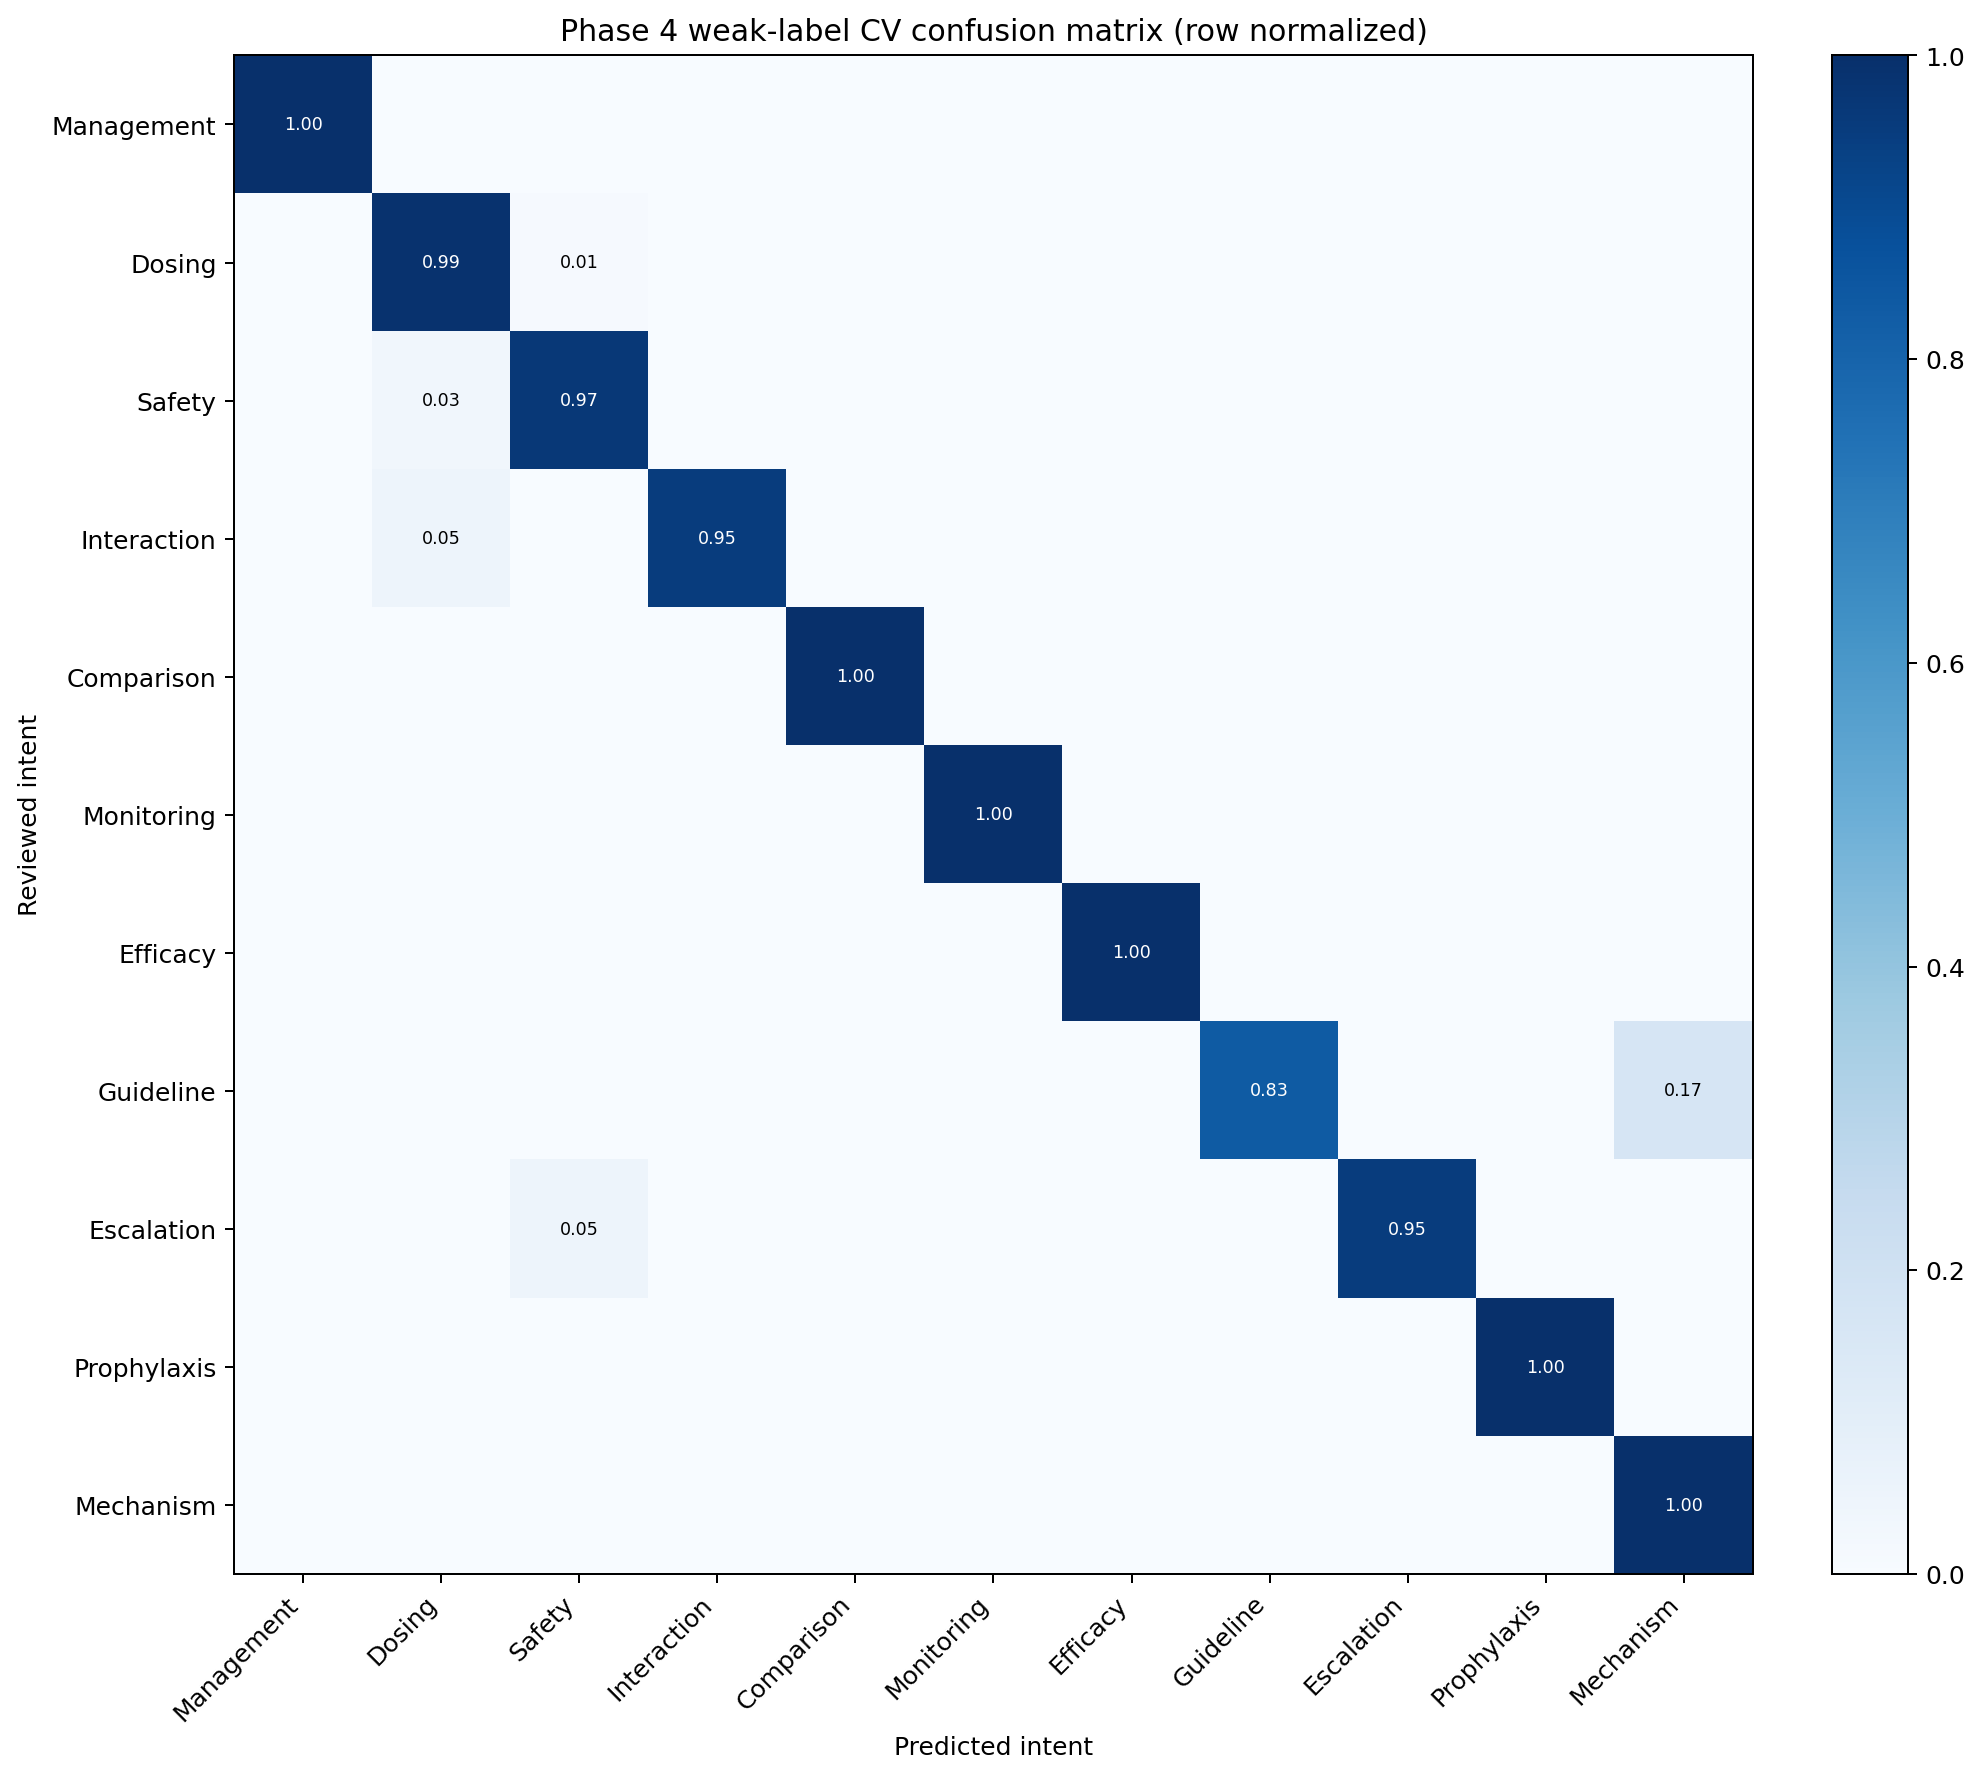

In [11]:
from IPython.display import Image, display
from src.intent_baseline import (
    CLASS_CHECKS_PATH, CONFUSION_FIGURE_PATH, FOLD_METRICS_PATH,
    GROUPED_SENSITIVITY_PATH, METRICS_PATH as PHASE4_METRICS_PATH,
    PER_CLASS_METRICS_PATH,
)

phase4_metrics = json.loads(PHASE4_METRICS_PATH.read_text(encoding='utf-8'))
display(pd.DataFrame([phase4_metrics['out_of_fold_metrics']]))
display(pd.read_csv(FOLD_METRICS_PATH))
display(pd.read_csv(PER_CLASS_METRICS_PATH))
display(pd.read_csv(CLASS_CHECKS_PATH))
display(pd.DataFrame([phase4_metrics['template_grouped_sensitivity']]))
display(Image(filename=str(CONFUSION_FIGURE_PATH)))

### Phase 4 decision and limitations

The baseline reaches 0.981 five-fold Macro F1 against the 362 retained weak labels (0.991 macro precision, 0.972 macro recall, 0.983 weighted F1, 0.983 accuracy). Top-level Macro F1 is 0.981. A zero-template-overlap sensitivity analysis reaches only 0.509 Macro F1 across the 10 classes with at least two templates; Monitoring / Response / Risk Assessment has only one retained template and cannot be assessed under an unseen-template split. `Other / Ambiguous` has no examples and cannot be learned.

The primary score measures reproduction of model-assisted weak labels, not clinical accuracy. The 84 prototype-plus-cluster-against-rule cases retain the schema-adjudicated rule target, and the two semantic signals are correlated because they share an encoder. The large row-CV versus grouped-sensitivity gap shows that recurring templates drive substantial performance. Both results are failure-analysis anchors rather than clinical-validity or production-readiness estimates.

## Phase 5: Improve Intent Classification

All Phase 5 supervised variants reuse the exact Phase 4 folds and 362 retained weak labels. The comparison includes final-taxonomy prototype similarity (T1-P0), the frozen Phase 4 lexical baseline (T1-B0), entity indicators/counts (T1-E1), entity plus Phase 1.6 contextual slots (T1-E2), cached frozen multilingual sentence embeddings with Logistic Regression (T1-E3), and early fusion of those embeddings with entity/context features (T1-E4). Model selection uses the zero-template-overlap stress test because row-stratified weak-label replication is already saturated.

In [12]:
# Phase 5 orchestration is notebook-owned; reusable experiment helpers remain in src/.
from pathlib import Path

from src.intent_improved import build_phase5_artifacts


def run_phase5() -> dict[str, Path]:
    """Run Phase 5 end to end and persist its auditable artifacts."""
    return build_phase5_artifacts()


phase5_paths = run_phase5()
phase5_paths

{'comparison': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/metrics/phase5_intent_improved_experiment_comparison.csv'),
 'predictions': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/metrics/phase5_intent_improved_predictions.csv'),
 'per_class_metrics': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/metrics/phase5_intent_improved_per_class_metrics.csv'),
 'prediction_changes': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/metrics/phase5_intent_improved_prediction_changes.csv'),
 'fusion_vs_embedding_changes': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/metrics/phase5_intent_improved_fusion_vs_embedding_changes.csv'),
 'errors': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/metrics/phase5_intent_improved_errors.csv'),
 'confusion_matrix': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/metrics/phase5_intent_improved_confusion_matrix.csv'),
 '

,protocol,experiment,representation,n_queries,n_classes,macro_f1,macro_precision,macro_recall,weighted_f1,accuracy,macro_f1_delta_vs_phase4
0,row_stratified,T1-B0,word TF-IDF,362,11,0.980765,0.991047,0.972142,0.983314,0.983425,0.000000
1,row_stratified,T1-E4,frozen embeddings + entity indicators/counts +...,362,11,0.970323,0.978522,0.964694,0.963753,0.964088,-0.010442
2,row_stratified,T1-E1,word TF-IDF + supplied entity indicators/counts,362,11,0.969292,0.984537,0.957614,0.971879,0.972376,-0.011473
3,row_stratified,T1-E3,frozen multilingual sentence embeddings,362,11,0.969006,0.977482,0.963154,0.960901,0.961326,-0.011759
4,row_stratified,T1-E2,word TF-IDF + entity indicators/counts + conte...,362,11,0.961431,0.970561,0.954246,0.948032,0.947514,-0.019333
5,row_stratified,T1-P0,final-taxonomy prototype similarity,362,11,0.683128,0.722298,0.756651,0.696153,0.704420,-0.297636
6,template_grouped,T1-E4,frozen embeddings + entity indicators/counts +...,354,10,0.842488,0.878134,0.833429,0.834949,0.841808,0.333385
7,template_grouped,T1-E3,frozen multilingual sentence embeddings,354,10,0.794411,0.804337,0.820395,0.780910,0.779661,0.285309
8,template_grouped,T1-E2,word TF-IDF + entity indicators/counts + conte...,354,10,0.678276,0.717934,0.677454,0.699583,0.711864,0.169173
9,template_grouped,T1-P0,final-taxonomy prototype similarity,354,10,0.651441,0.694527,0.732316,0.689287,0.697740,0.142338


,protocol,experiment,intent,precision,recall,f1,support
11,template_grouped,T1-B0,Management / Treatment Selection,0.675000,0.540000,0.600000,50
12,template_grouped,T1-B0,Dosing / Administration,0.507463,0.723404,0.596491,94
13,template_grouped,T1-B0,Safety / Contraindication,0.437500,0.593220,0.503597,59
14,template_grouped,T1-B0,Interaction / Combination,0.428571,0.285714,0.342857,21
15,template_grouped,T1-B0,Comparative Treatment Choice,0.583333,0.913043,0.711864,23
16,template_grouped,T1-B0,Efficacy / Outcomes,0.000000,0.000000,0.000000,20
17,template_grouped,T1-B0,Guideline / Evidence Lookup,1.000000,0.833333,0.909091,6
18,template_grouped,T1-B0,Treatment Change / Escalation,0.500000,0.238095,0.322581,21
19,template_grouped,T1-B0,Prophylaxis / Maintenance,0.750000,0.580645,0.654545,31
20,template_grouped,T1-B0,Mechanism / Background Knowledge,0.818182,0.310345,0.450000,29


,true_intent,predicted_intent,n_errors,true_intent_support,share_of_true_intent
0,Safety / Contraindication,Dosing / Administration,14,59,0.237288
1,Prophylaxis / Maintenance,Management / Treatment Selection,12,31,0.387097
2,Management / Treatment Selection,Prophylaxis / Maintenance,7,50,0.140000
3,Interaction / Combination,Comparative Treatment Choice,6,21,0.285714
4,Management / Treatment Selection,Safety / Contraindication,6,50,0.120000
5,Interaction / Combination,Management / Treatment Selection,5,21,0.238095
6,Management / Treatment Selection,Mechanism / Background Knowledge,2,50,0.040000
7,Safety / Contraindication,Mechanism / Background Knowledge,2,59,0.033898
8,Guideline / Evidence Lookup,Management / Treatment Selection,1,6,0.166667
9,Safety / Contraindication,Prophylaxis / Maintenance,1,59,0.016949


,protocol,experiment,slice_type,slice_value,n_queries,n_true_classes,macro_f1,macro_precision,macro_recall,weighted_f1,accuracy
72,template_grouped,T1-E3,language,EN,154,10,0.918203,0.929074,0.929242,0.919767,0.922078
73,template_grouped,T1-E3,language,ID,88,7,0.579291,0.610638,0.613585,0.682672,0.681818
74,template_grouped,T1-E3,language,MIXED,112,9,0.620871,0.641803,0.632748,0.687174,0.660714
75,template_grouped,T1-E3,signal_agreement,prototype_cluster_against_rule,84,5,0.378168,0.372917,0.400641,0.562023,0.583333
76,template_grouped,T1-E3,signal_agreement,two_signal_including_rule,127,7,0.586237,0.613571,0.578639,0.786981,0.732283
77,template_grouped,T1-E3,signal_agreement,unanimous,143,5,0.940972,0.928000,0.971875,0.941591,0.937063
78,template_grouped,T1-E3,query_length,4-7 tokens,210,10,0.847811,0.848555,0.891041,0.835806,0.833333
79,template_grouped,T1-E3,query_length,8+ tokens,144,9,0.698065,0.711899,0.726841,0.697417,0.701389


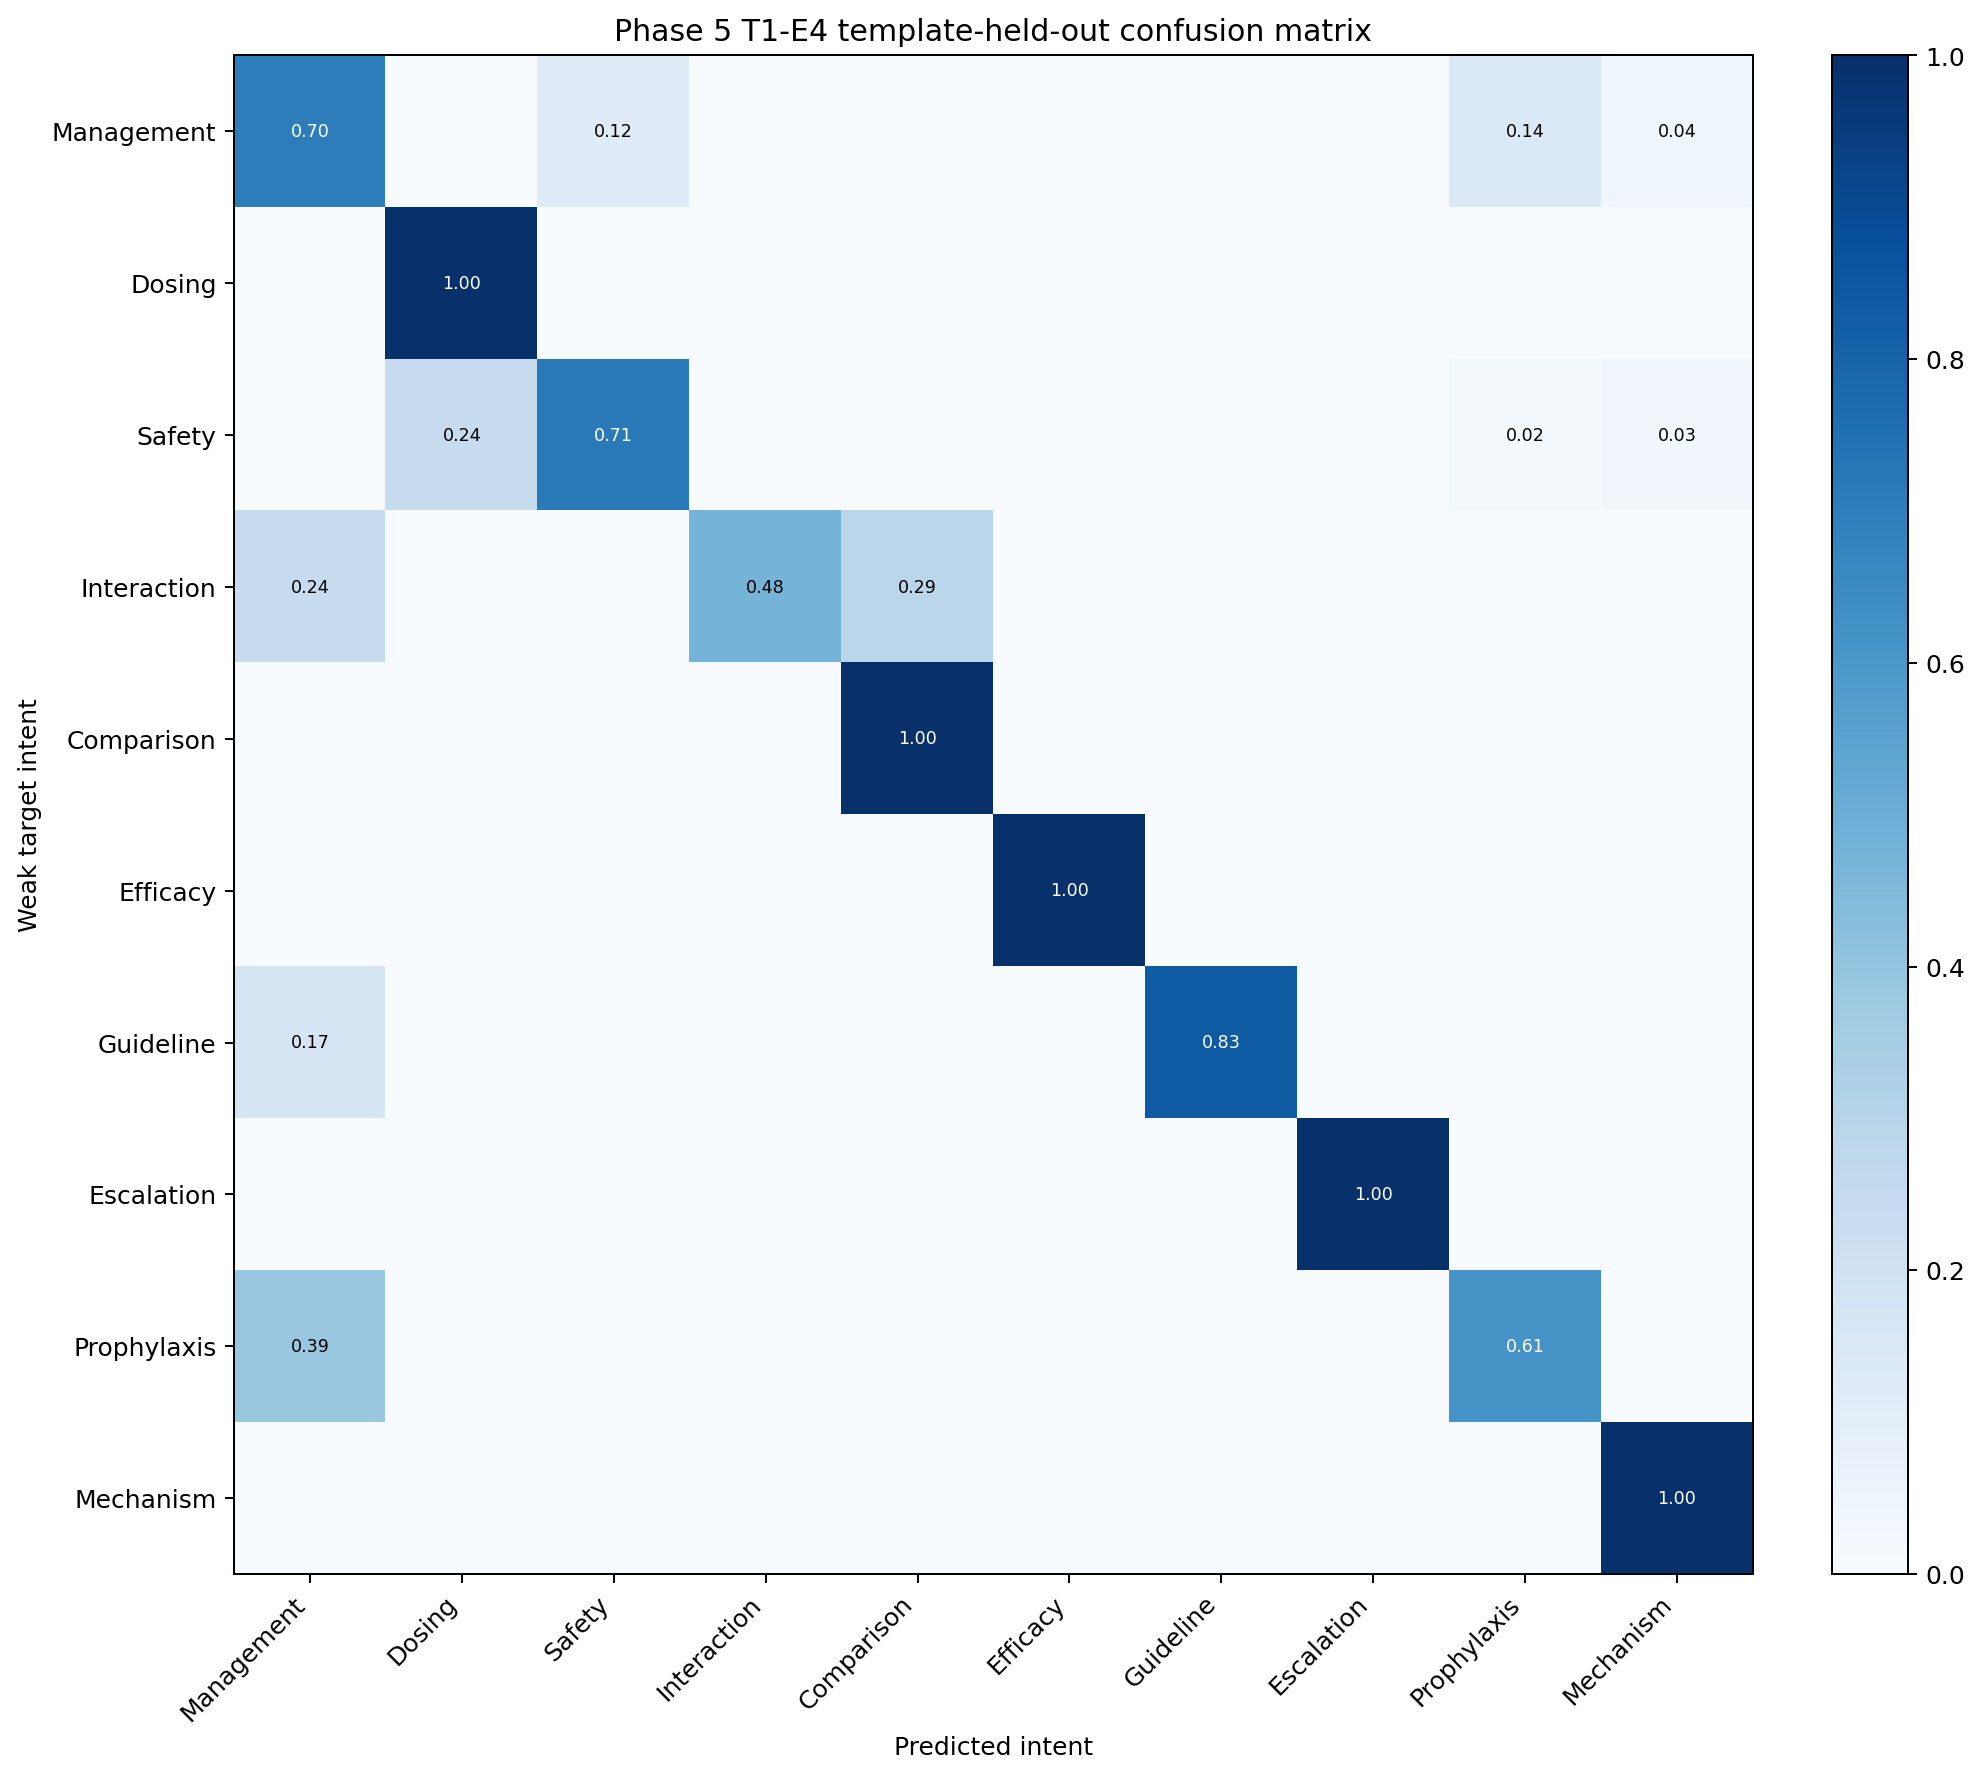

In [13]:
from src.intent_improved import (
    COMPARISON_PATH as PHASE5_COMPARISON_PATH,
    CONFUSION_FIGURE_PATH as PHASE5_CONFUSION_FIGURE_PATH,
    CONFUSION_PAIRS_PATH as PHASE5_CONFUSION_PAIRS_PATH,
    PER_CLASS_PATH as PHASE5_PER_CLASS_PATH,
    SLICE_METRICS_PATH as PHASE5_SLICE_METRICS_PATH,
)

display(pd.read_csv(PHASE5_COMPARISON_PATH))
display(pd.read_csv(PHASE5_PER_CLASS_PATH).query("protocol == 'template_grouped'"))
display(pd.read_csv(PHASE5_CONFUSION_PAIRS_PATH).head(12))
display(pd.read_csv(PHASE5_SLICE_METRICS_PATH).query("protocol == 'template_grouped' and experiment == 'T1-E3'"))
display(Image(filename=str(PHASE5_CONFUSION_FIGURE_PATH)))

### Phase 5 decision and limitations

T1-E4 is selected: fixed early fusion raises template-held-out Macro F1 to 0.842, an absolute +0.333 over Phase 4's 0.509 and +0.048 over embedding-only T1-E3. Its row-stratified weak-label Macro F1 is 0.970 versus 0.981 for Phase 4. Entity presence/count features alone are effectively neutral at 0.514, contextual slots with TF-IDF reach 0.678, and the embedding/context combination provides the best unseen-template result. The largest remaining confusions are Safety vs Dosing, Prophylaxis vs general Management, Interaction vs Comparison/Management, and Management vs Safety/Prophylaxis.

These are weak-label results, not clinical accuracy. Monitoring remains impossible to evaluate without template leakage, `Other / Ambiguous` has no examples, and the embedding representation contributed to Phase 3 prototype/cluster signals used for evaluation-row filtering. E4 therefore shows promising formulation transfer within this dataset, not an independent clinical benchmark.

## Phase 6: Build the Query-Content Behavioral Table

The analytical unit is one `(query_id, content_id, session_id)` impression. Impressions define the complete row universe, while behavioral signals are aggregated and left-joined. Query intent, supplied entities, and Phase 1.6 contextual slots come from the labeled query table; content metadata and entities come from the content table. This phase constructs behavior features only and deliberately does not assign relevance labels.

In [14]:
# Phase 6 orchestration is notebook-owned; join and validation helpers remain in src/.
from pathlib import Path

from src.relevance import build_phase6_artifacts


def run_phase6() -> dict[str, Path]:
    """Run Phase 6 end to end and persist its auditable artifacts."""
    return build_phase6_artifacts()


phase6_paths = run_phase6()
phase6_paths

{'behavioral_table': PosixPath('/Users/hol/Documents/Task/doctor-search-service/data/processed/query_content_behavioral.csv'),
 'event_summary': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/phase6_behavioral_event_summary.csv'),
 'metrics': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/phase6_behavioral_table_metrics.json'),
 'report': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/phase6_behavioral_table_report.md')}

In [15]:
from src.relevance import (
    BEHAVIORAL_TABLE_PATH as PHASE6_TABLE_PATH,
    EVENT_SUMMARY_PATH as PHASE6_EVENT_SUMMARY_PATH,
    METRICS_PATH as PHASE6_METRICS_PATH,
)

phase6_metrics = json.loads(PHASE6_METRICS_PATH.read_text(encoding='utf-8'))
display(pd.DataFrame([phase6_metrics]).drop(columns=['source_rows', 'event_flag_counts']))
display(pd.read_csv(PHASE6_EVENT_SUMMARY_PATH))
display(pd.read_csv(PHASE6_TABLE_PATH).head(10))

,orphan_impression_queries,orphan_impression_content,orphan_behavioral_signals,doctor_id_mismatches,negative_event_latency,duplicate_impression_units_collapsed,analytical_rows,unique_analytical_units,queries_represented,content_represented,sessions_represented,doctors_represented,engaged_rows,unengaged_rows,engagement_rate,behavioral_events_linked,dwell_seconds_total,dwell_seconds_median_engaged,relevance_labels_assigned
0,0,0,0,0,0,0,7190,7190,500,345,813,118,1500,5690,0.208623,1500,95140,23.0,False


,event_type,analytical_rows,share_of_all_rows,median_dwell_seconds,mean_dwell_seconds,max_dwell_seconds
0,click,944,0.131293,10.5,14.454449,111
1,scroll_deep,436,0.060640,152.0,150.965596,239
2,return_visit,29,0.004033,213.0,224.586207,353
3,save_bookmark,91,0.012656,94.0,100.670330,179
4,no_observed_engagement,5690,0.791377,0.0,0.000000,0


,query_id,content_id,session_id,impression_id,doctor_id,timestamp,last_timestamp_served,inferred_rank,impression_count,impressed,...,behavioral_event_count,first_event_timestamp,last_event_timestamp,clicked,scroll_deep,return_visit,save_bookmark,dwell_time,max_event_dwell_seconds,has_engagement
0,Q429,C252,SE0440,IMP0001,D119,2025-01-01 00:05:55,2025-01-01 00:05:55,1,1,True,...,0,NaN,NaN,False,False,False,False,0,0,False
1,Q429,C047,SE0440,IMP0002,D119,2025-01-01 00:05:56,2025-01-01 00:05:56,2,1,True,...,0,NaN,NaN,False,False,False,False,0,0,False
2,Q429,C321,SE0440,IMP0003,D119,2025-01-01 00:05:58,2025-01-01 00:05:58,3,1,True,...,0,NaN,NaN,False,False,False,False,0,0,False
3,Q429,C277,SE0440,IMP0004,D119,2025-01-01 00:06:02,2025-01-01 00:06:02,4,1,True,...,0,NaN,NaN,False,False,False,False,0,0,False
4,Q429,C104,SE0440,IMP0005,D119,2025-01-01 00:06:06,2025-01-01 00:06:06,5,1,True,...,0,NaN,NaN,False,False,False,False,0,0,False
5,Q429,C315,SE0440,IMP0006,D119,2025-01-01 00:06:06,2025-01-01 00:06:06,6,1,True,...,0,NaN,NaN,False,False,False,False,0,0,False
6,Q429,C303,SE0440,IMP0007,D119,2025-01-01 00:06:07,2025-01-01 00:06:07,7,1,True,...,0,NaN,NaN,False,False,False,False,0,0,False
7,Q429,C217,SE0440,IMP0008,D119,2025-01-01 00:06:07,2025-01-01 00:06:07,8,1,True,...,0,NaN,NaN,False,False,False,False,0,0,False
8,Q429,C037,SE0440,IMP0009,D119,2025-01-01 00:06:10,2025-01-01 00:06:10,9,1,True,...,1,2025-01-01 00:06:27,2025-01-01 00:06:27,True,False,False,False,0,0,True
9,Q448,C078,SE0796,IMP0010,D049,2025-01-01 01:34:58,2025-01-01 01:34:58,1,1,True,...,0,NaN,NaN,False,False,False,False,0,0,False


### Phase 6 decision and limitations

The final table contains 7,190 unique analytical units spanning all 500 queries, 345 content items, and 813 sessions. All 1,500 behavioral signals join to an impression with consistent doctor IDs and valid event timing. Engagement is observed for 1,500 rows (20.9%); the remaining 5,690 rows are retained as unengaged impressions, not labeled negatives. Event flags reproduce the raw counts: 944 clicks, 436 deep scrolls, 91 bookmarks, and 29 return visits.

Exact age, eGFR, and disease severity are not present because Phase 1.6 did not extract them; age group and renal-function group are included instead. Query intent remains a model-assisted weak label, and `inferred_rank` is serving order rather than a supplied position field. Behavioral relevance grading is intentionally deferred to Phase 7.

### Relevance-focused EDA for Phase 7

Before fixing relevance grades, inspect event semantics, dwell-time distributions, inferred-position bias, queries without positive behavior, repeated query-content consistency, descriptive slices, and exact structured-match sanity checks. The candidate schemes below are sensitivity analyses only; they are not written into the Phase 6 table.

In [16]:
from src.relevance_eda import build_relevance_eda_artifacts

phase6_eda_paths = build_relevance_eda_artifacts()
phase6_eda_paths

{'metrics': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/eda/phase6_relevance_eda_metrics.json'),
 'report': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/eda/phase6_relevance_eda_report.md'),
 'dwell_distribution': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/eda/dwell_distribution_by_event.csv'),
 'threshold_sensitivity': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/eda/dwell_threshold_sensitivity.csv'),
 'position': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/eda/engagement_by_inferred_rank.csv'),
 'slices': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/eda/engagement_slices.csv'),
 'session_distribution': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/eda/session_engagement_distribution.csv'),
 'repeatability': PosixPath('/Users/hol/Documents/Task/doctor-search-ser

,analytical_rows,engaged_rows,event_types_mutually_exclusive,rows_with_multiple_event_types,click_zero_dwell_rows,click_dwell_median,click_dwell_p75,scroll_dwell_min,scroll_dwell_median,rank1_engagement_rate,...,rank1_absolute_lift,sessions,sessions_without_engagement,queries,queries_without_engagement,unique_query_content_pairs,repeated_query_content_pairs,mixed_repeat_pairs,candidate_grades_written_to_behavioral_table,eda_is_descriptive_not_causal
0,7190,1500,True,0,66,10.5,20.0,61,152.0,0.241082,...,0.036598,813,150,500,150,7037,150,49,False,True


,event_type,rows,zero_dwell_rows,mean_seconds,p00,p05,p10,p25,p50,p75,p90,p95,p100
0,click,944,66,14.454449,0.0,0.0,1.0,3.0,10.5,20.00,34.0,46.85,111.0
1,scroll_deep,436,0,150.965596,61.0,67.0,77.0,104.0,152.0,195.25,221.5,229.00,239.0
2,return_visit,29,0,224.586207,92.0,124.0,124.0,160.0,213.0,302.00,315.6,334.00,353.0
3,save_bookmark,91,0,100.670330,31.0,35.5,40.0,60.5,94.0,142.50,172.0,175.50,179.0


,event_type,threshold_seconds,below_threshold,at_or_above_threshold,share_at_or_above
0,click,5,297,647,0.685381
1,click,10,444,500,0.529661
2,click,20,703,241,0.255297
3,click,30,811,133,0.140890
4,scroll_deep,90,76,360,0.825688
5,scroll_deep,120,142,294,0.674312
6,scroll_deep,150,210,226,0.518349
7,scroll_deep,180,285,151,0.346330


,inferred_rank,impressions,engaged,engagement_rate,engagement_ci95_low,engagement_ci95_high,click_rate,scroll_deep_rate,save_bookmark_rate,return_visit_rate,median_dwell_engaged
0,1,813,196,0.241082,0.212941,0.271659,0.163592,0.070111,0.004920,0.002460,19.0
1,2,813,162,0.199262,0.173247,0.228106,0.123001,0.063961,0.012300,0.000000,25.0
2,3,813,180,0.221402,0.194209,0.251216,0.130381,0.068881,0.015990,0.006150,27.0
3,4,813,163,0.200492,0.174408,0.229393,0.124231,0.054121,0.014760,0.007380,22.0
4,5,813,164,0.201722,0.175570,0.230680,0.125461,0.056581,0.017220,0.002460,23.5
5,6,792,155,0.195707,0.169572,0.224780,0.118687,0.058081,0.013889,0.005051,29.0
6,7,679,142,0.209131,0.180220,0.241315,0.134021,0.060383,0.010309,0.004418,25.5
7,8,567,115,0.202822,0.171775,0.237869,0.126984,0.059965,0.014109,0.001764,20.0
8,9,456,98,0.214912,0.179674,0.254914,0.133772,0.065789,0.006579,0.008772,17.5
9,10,323,64,0.198142,0.158331,0.245050,0.142415,0.037152,0.015480,0.003096,13.5


,repeatability,query_content_pairs,total_exposures,total_engaged_exposures,share_of_pairs,engagement_rate
0,repeated_always_engaged,10,20,20,0.001421,1.000000
1,repeated_mixed_engagement,49,100,49,0.006963,0.490000
2,repeated_never_engaged,91,183,0,0.012932,0.000000
3,single_exposure,6887,6887,1431,0.978684,0.207783


,scheme,definition,grade,rows,share_all_rows,share_engaged_rows
0,event_hierarchy,3=bookmark/return; 2=deep scroll; 1=click; 0=n...,0,5690,0.791377,0.000000
1,event_hierarchy,3=bookmark/return; 2=deep scroll; 1=click; 0=n...,1,944,0.131293,0.629333
2,event_hierarchy,3=bookmark/return; 2=deep scroll; 1=click; 0=n...,2,436,0.060640,0.290667
3,event_hierarchy,3=bookmark/return; 2=deep scroll; 1=click; 0=n...,3,120,0.016690,0.080000
4,median_dwell_split,3=bookmark/return or deep scroll >=150s; 2=oth...,0,5690,0.791377,0.000000
5,median_dwell_split,3=bookmark/return or deep scroll >=150s; 2=oth...,1,444,0.061752,0.296000
6,median_dwell_split,3=bookmark/return or deep scroll >=150s; 2=oth...,2,710,0.098748,0.473333
7,median_dwell_split,3=bookmark/return or deep scroll >=150s; 2=oth...,3,346,0.048122,0.230667
8,conservative_dwell,3=bookmark/return or deep scroll >=180s; 2=oth...,0,5690,0.791377,0.000000
9,conservative_dwell,3=bookmark/return or deep scroll >=180s; 2=oth...,1,811,0.112796,0.540667


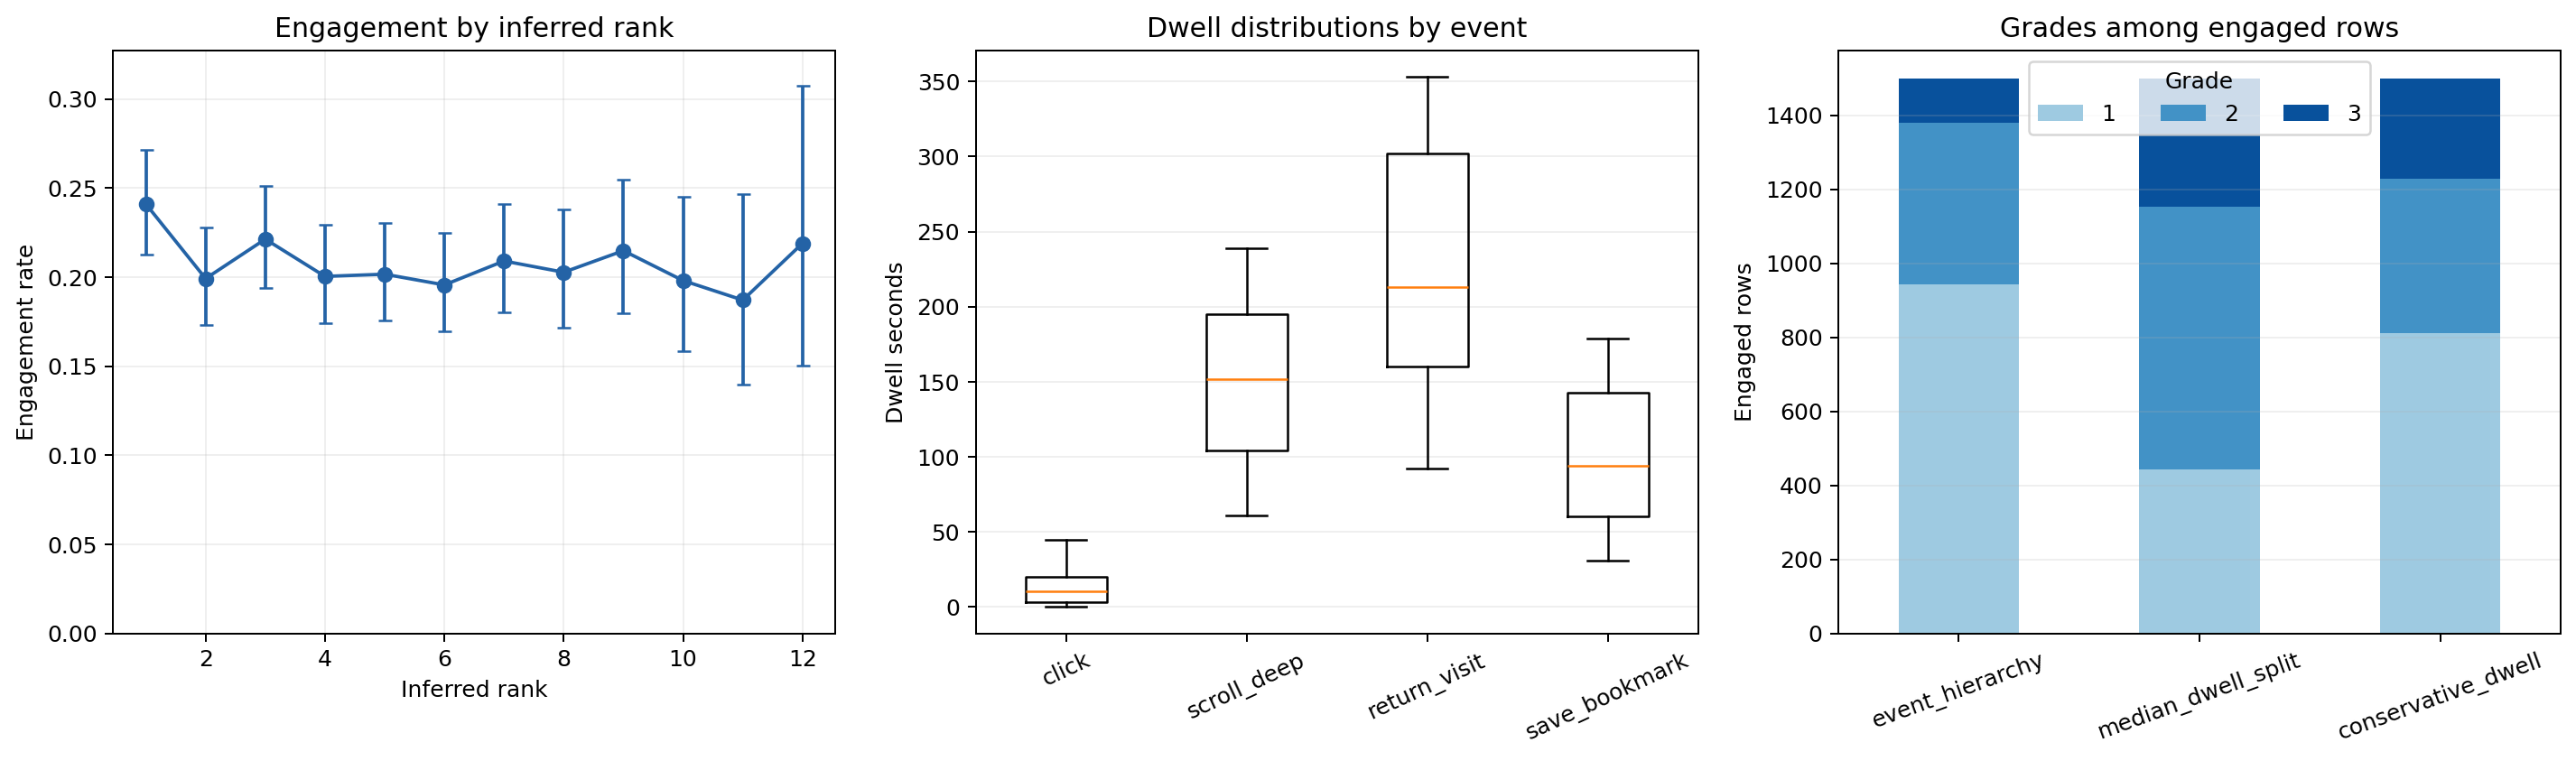

In [17]:
from src.relevance_eda import (
    CANDIDATE_SCHEMES_PATH, DWELL_DISTRIBUTION_PATH, EDA_FIGURE_PATH,
    EDA_METRICS_PATH, POSITION_PATH, REPEATABILITY_PATH,
    THRESHOLD_SENSITIVITY_PATH,
)

display(pd.DataFrame([json.loads(EDA_METRICS_PATH.read_text(encoding='utf-8'))]))
display(pd.read_csv(DWELL_DISTRIBUTION_PATH))
display(pd.read_csv(THRESHOLD_SENSITIVITY_PATH))
display(pd.read_csv(POSITION_PATH))
display(pd.read_csv(REPEATABILITY_PATH))
display(pd.read_csv(CANDIDATE_SCHEMES_PATH))
display(Image(filename=str(EDA_FIGURE_PATH)))

#### EDA implications for Phase 7

Every engaged row contains exactly one event type, so these fields should be interpreted as mutually exclusive terminal outcomes rather than a complete click-to-scroll-to-bookmark funnel. Click dwell has median 10.5 seconds (p75 20 seconds), while deep scroll starts at 61 seconds and has median 152 seconds. A 30-second click cutoff retains only 14.1% of clicks, versus 25.5% at 20 seconds and 53.0% at 10 seconds; multiple thresholds should therefore be reported.

Rank-one engagement is 24.1% versus 20.4% at later ranks. There are 150 queries with no observed engagement, so coverage must accompany positive-dependent retrieval metrics. Of 150 query-content pairs repeated across sessions, 49 have mixed engaged/unengaged outcomes, which argues for retaining session-level evidence and marking conflict when aggregating. Grade 0 should remain `exposed without observed engagement`, never asserted ground-truth irrelevance.

### Additional bias diagnostics

The behavior table is observational and was produced by an existing exposure and logging process. Additional diagnostics screen judgment-pool coverage, session-length construction, doctor propensity, content popularity, representation, inferred-rank ties, and temporal coverage. Associations are descriptive and cannot identify causal bias.

In [18]:
from src.relevance_bias_eda import build_bias_eda_artifacts

phase6_bias_paths = build_bias_eda_artifacts()
phase6_bias_paths

{'metrics': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/eda/bias/bias_diagnostics_metrics.json'),
 'report': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/eda/bias/bias_diagnostics_report.md'),
 'query_coverage': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/eda/bias/query_judgment_coverage.csv'),
 'session_length': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/eda/bias/session_length_bias.csv'),
 'doctor_propensity': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/eda/bias/doctor_engagement_propensity.csv'),
 'content_exposure': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/eda/bias/content_exposure_bias.csv'),
 'representation': PosixPath('/Users/hol/Documents/Task/doctor-search-service/outputs/relevance/eda/bias/inventory_vs_exposure_representation.csv'),
 'temporal': PosixPath('/Users/hol/Documents/

,possible_query_content_pairs,observed_query_content_pairs,unjudged_query_content_pairs,global_judgment_coverage,minimum_query_judgment_coverage,median_query_judgment_coverage,maximum_query_judgment_coverage,queries_without_positive,no_positive_queries_with_multiple_sessions,five_result_sessions,...,content_exposure_engagement_p_value_naive,query_intent_min_representation_ratio,query_intent_max_representation_ratio,timestamp_tied_impression_share,date_start,date_end,date_span_days,weekly_rate_min,weekly_rate_max,causal_claims_supported
0,172500,7037,165463,0.040794,0.014493,0.028986,0.223188,150,0,21,...,1.288914e-44,0.868435,1.223015,0.238248,2025-01-01 00:05:55,2025-01-30 22:22:29,30,0.188138,0.234886,False


,list_length,sessions,sessions_with_engagement,session_any_engagement_rate,impressions,engaged_impressions,per_impression_engagement_rate,per_impression_ci95_low,per_impression_ci95_high,mean_engaged_results_per_session
0,5,21,0,0.000000,105,0,0.000000,0.000000,0.035295,0.000000
1,6,113,89,0.787611,678,183,0.269912,0.237862,0.304554,1.619469
2,7,112,88,0.785714,784,187,0.238520,0.210008,0.269582,1.669643
3,8,111,88,0.792793,888,173,0.194820,0.170107,0.222162,1.558559
4,9,133,102,0.766917,1197,260,0.217210,0.194774,0.241454,1.954887
5,10,120,93,0.775000,1200,210,0.175000,0.154548,0.197526,1.750000
6,11,98,98,1.000000,1078,230,0.213358,0.189942,0.238810,2.346939
7,12,105,105,1.000000,1260,257,0.203968,0.182634,0.227102,2.447619


,variable,groups,cramers_v,chi_square_p_value_naive,minimum_expected_cell,minimum_group_rate,maximum_group_rate,rate_range,clustered_rows_caveat
0,doctor_id,118,0.224292,8.485549e-27,1.251739,0.000000,0.800000,0.800000,True
1,content_source_type,12,0.116473,5.476157e-16,22.114047,0.037736,0.262832,0.225096,True
2,session_length,8,0.089379,4.890748e-10,21.905424,0.000000,0.269912,0.269912,True
3,content_type,6,0.083095,1.638039e-09,54.659249,0.083969,0.239027,0.155057,True
4,query_intent,11,0.062013,2.053213e-03,56.954103,0.117216,0.270358,0.153142,True
5,content_publication_year,6,0.051196,2.053708e-03,188.386648,0.177187,0.231418,0.054230,True
6,week,5,0.038081,3.382431e-02,206.328234,0.188138,0.234886,0.046748,True
7,inferred_rank,12,0.035102,6.349105e-01,21.905424,0.187192,0.241082,0.053890,True
8,content_language,3,0.018185,3.045861e-01,245.757997,0.197198,0.214443,0.017245,True
9,query_language,3,0.014652,4.622014e-01,348.817803,0.200557,0.214115,0.013558,True


,impressions,tied_timestamp_groups,impressions_in_tied_groups,share_impressions_in_tied_groups,extra_rows_beyond_first_in_ties,largest_tied_group,tie_breaker
0,7190,765,1713,0.238248,948,7,impression_id


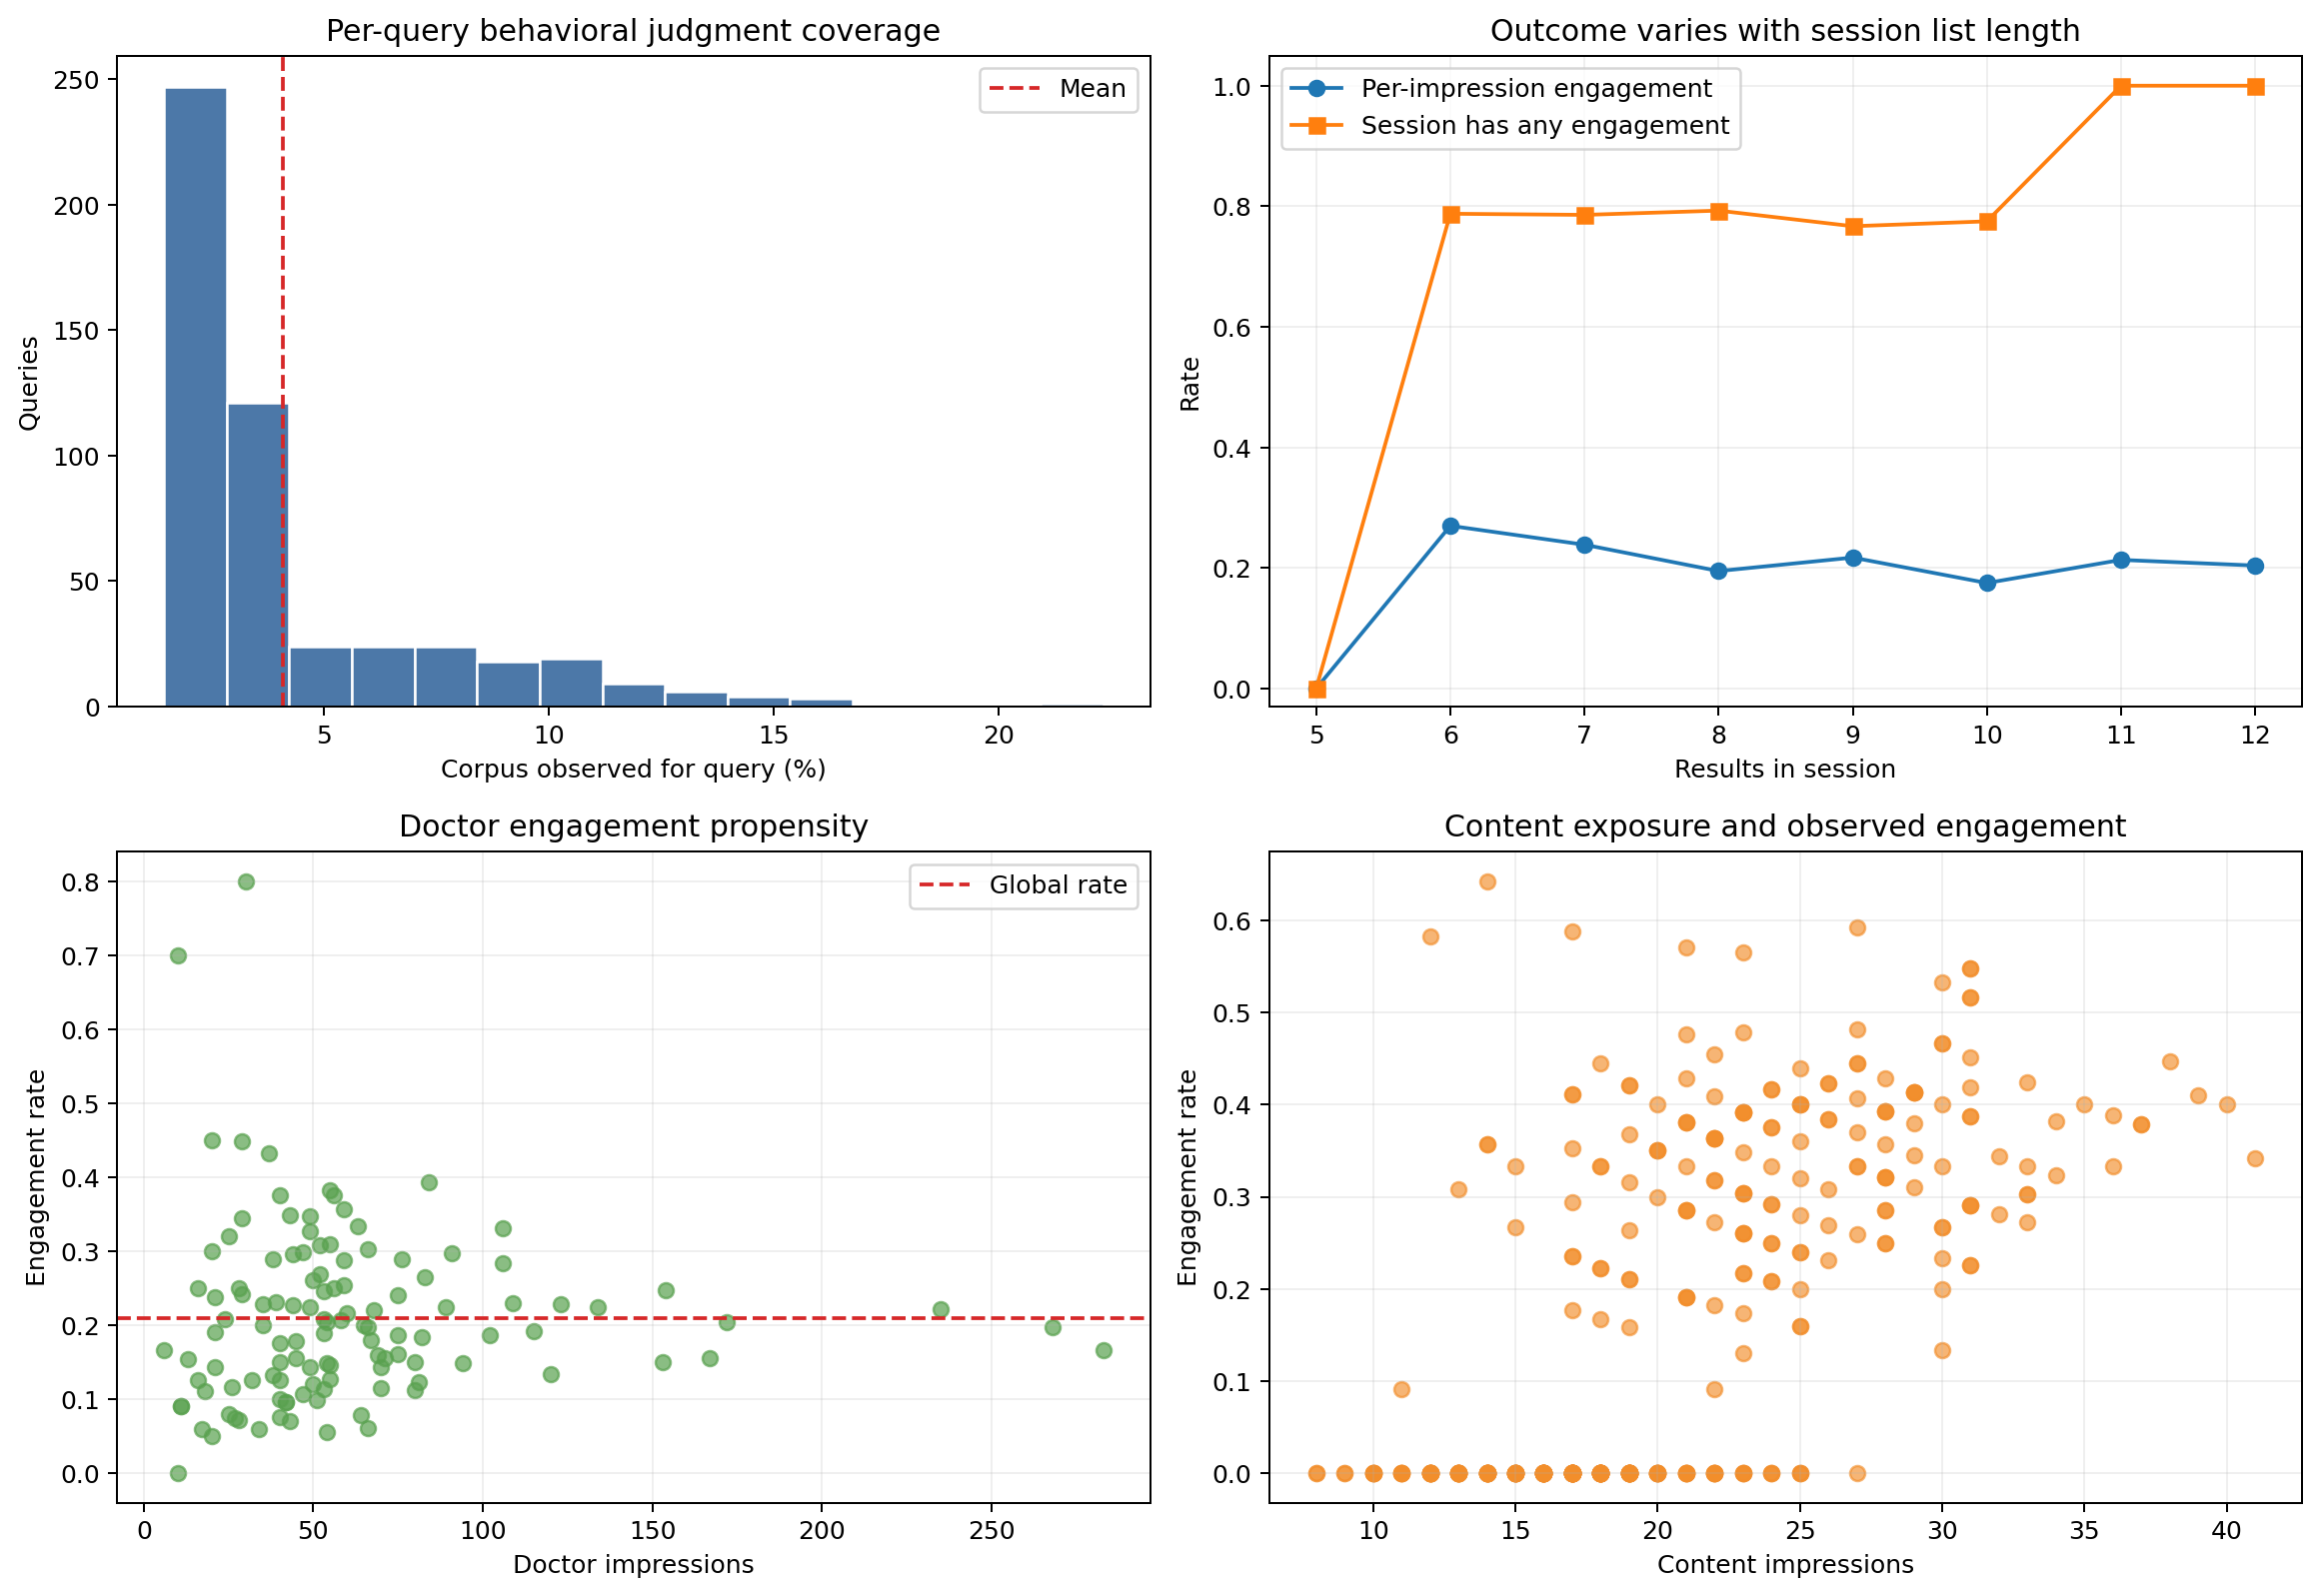

In [19]:
from src.relevance_bias_eda import (
    ASSOCIATION_PATH, BIAS_FIGURE_PATH, BIAS_METRICS_PATH,
    SESSION_LENGTH_PATH, TIMESTAMP_TIES_PATH,
)

display(pd.DataFrame([json.loads(BIAS_METRICS_PATH.read_text(encoding='utf-8'))]))
display(pd.read_csv(SESSION_LENGTH_PATH))
display(pd.read_csv(ASSOCIATION_PATH))
display(pd.read_csv(TIMESTAMP_TIES_PATH))
display(Image(filename=str(BIAS_FIGURE_PATH)))

#### Bias findings and safeguards

Only 7,037 of 172,500 possible query-content pairs are behaviorally observed (4.1%), so unshown documents must remain unjudged. Session opportunity appears outcome-conditioned: every five-result session has no engagement, every 11- or 12-result session has engagement, and every multi-session query has at least one positive. Doctor propensity varies substantially, and content exposure count correlates strongly with engagement rate (Spearman rho 0.661).

Serving timestamps tie for 23.8% of impressions, weakening inferred-rank analyses. Logs cover only 30 days, so temporal drift cannot be assessed. Phase 7 should exclude exposure count, session length, doctor/content IDs, source type, and inferred rank from the grade rule; preserve them only for grouped validation, bias slices, and sensitivity analysis.

## Task 1: Intent Taxonomy and Classifier

Define a doctor-centered intent taxonomy, label queries, train a small-data classifier, and inspect failure cases.

## Task 2: Retrieval and Evaluation

Construct behavior-derived relevance labels, build a BM25 baseline, and evaluate structured, semantic, hybrid, and intent-aware retrieval variants.

## What I Would Build Next

Summarize higher-effort extensions and productionization ideas that are out of scope for the CPU-first baseline.